# Intro

Models will be trained and tuned in this notebook. Data preprocessing will be based on the results of the EDA performed in another notebook.

The main metric is Recall@5% FPR, i.e. the share of correctly identified fraudulent applications among all fraudulent applications, provided that false positive predictions do not exceed 5% of all applications. Thus, this metric takes into account the business interests of the company, since a large share of false positive predictions contributes to the deterioration of user experience and customer churn.

The goal of the work is to obtain the model, showing the best results in cross-validation.
To achieve the goal, the following tasks are set:
- train a simple baseline-model, make quality measurements
- train more complex models
- conduct Time Series cross-validation based on the value of the Month column
- select 2 best models
- use a statistical test to select the best model

# Imports

In [1]:
import datetime

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from scipy.stats import t, ttest_rel
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, auc, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay, \
    make_scorer, check_scoring, brier_score_loss, log_loss
from sklearn.model_selection import BaseCrossValidator, TimeSeriesSplit, cross_validate, cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.svm import LinearSVC
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier

from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

PROJECT_ROOT = Path.cwd().parent

## Train-Test Split
Months 6, 7 go to the test part. The division is 80/20.

In [2]:
df = pd.read_csv(PROJECT_ROOT / "data" / "Bank Account Fraud Dataset" / "account_fraud.csv")

X_train, y_train = df[~df.month.isin([6, 7])].drop(['fraud_bool'], axis=1), df[~df.month.isin([6, 7])]['fraud_bool']
X_test, y_test = df[df.month.isin([6, 7])].drop(['fraud_bool'], axis=1), df[df.month.isin([6, 7])]['fraud_bool']

del df

# Declaring classes to preprocess data and functions

I will import several classes for data processing:
- TimeSeriesMonthSplit - a custom class for performing cross-validation splits based on the Month column;
- NoneHandler - a custom class for handling missing values;
- DataHandler - a custom class for dataset processing (similar to what was done in the EDA notebook);
- DataPreprocessor - a custom class for feature selection, feature engineering (adding features based on functions and PCA), and applying a ColumnTransformer (including Scaler, OHE, MTE);
- IsoForest - a custom class for adding a feature obtained using IsolationForest.

In [3]:
from DataTransformer import TimeSeriesMonthSplit, NoneHandler, DataHandler, DataPreprocessor, IsoForest

Declare the metric function

In [4]:
def recall_at_fpr_threshold(y_true, y_scores, fpr_threshold=0.05):
    """
    the metric function
    """    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    valid = np.where(fpr <= fpr_threshold)[0].max()
    return tpr[valid]


recall_a5_fpr = make_scorer(
    recall_at_fpr_threshold,
    greater_is_better=True,
    response_method=['predict_proba', 'decision_function'],
)

Declare the report fucntion 

In [5]:
def model_report(model, X_train, y_train, X_test, y_test):
    """
    the report fucntion
    """

    def make_roc_curve(fpr, tpr, auc, ax, color='orange', title='Test'):
        ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})", color=color)
        ax.plot([0, 1], [0, 1], 'k--')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{title} ROC Curve")
        ax.grid()
        ax.legend()

    def make_pr_curve(precision, recall, auc, ax, color='orange', title='Test'):
        ax.plot(recall, precision, label=f"PR curve (AUC = {auc:.4f})", color=color)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"{title} PR Curve")
        ax.grid()
        ax.legend()

    if not isinstance(model, Pipeline):
        est = model
    else:
        est = model[-1]
        while isinstance(est, Pipeline):
            est = est[-1]
        
    if 'predict_proba' in dir(est):
        y_score_ = model.predict_proba(X_train)[:,1]
        y_score = model.predict_proba(X_test)[:,1]
        y_pred = (y_score >= 0.5).astype(int)
    
    elif 'decision_function' in dir(est):
        y_score_ = model.decision_function(X_train)
        y_score = model.decision_function(X_test)
        y_pred = (y_score >= 0.0).astype(int)  # 0.0 is similar to 0.5-threshold of logistic regression

    else:
        raise ValueError
    
    fig, axes = plt.subplots(3, 2, figsize=(10, 15))

    fpr_, tpr_, thresholds_ = roc_curve(y_train, y_score_)
    roc_auc_ = roc_auc_score(y_train, y_score_)
    make_roc_curve(fpr=fpr_, tpr=tpr_, auc=roc_auc_, ax=axes[1][0], color='blue', title='Train')

    
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    make_roc_curve(fpr=fpr, tpr=tpr, auc=roc_auc, ax=axes[1][1])

    idx = np.where(fpr <= 0.05)[0].max()  # index FPR<=5%
    threshold_5_fpr = thresholds[idx]


    precision_, recall_, _ = precision_recall_curve(y_train, y_score_)
    pr_auc_ = auc(recall_, precision_)
    make_pr_curve(precision_, recall_, auc=pr_auc_, ax=axes[0][0], color='blue', title='Train')

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = auc(recall, precision)
    make_pr_curve(precision, recall, auc=pr_auc, ax=axes[0][1])
    

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_).plot(ax=axes[2][0])
    axes[2][0].set_title('Confusion Matrix')


    cm = confusion_matrix(y_test, (y_score >= threshold_5_fpr).astype(int), labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_).plot(ax=axes[2][1])
    axes[2][1].set_title(f'Confusion Matrix, \n Recall@5% FPR {np.round(tpr[idx], 3)}')

    return fig, axes

I will preprocess all cross-validation splits, combine them into a single DataFrame, and return the indexes of each split. This will significantly speed up cross-validation but will require more RAM

In [6]:
def preprocess(preprocessor, X_train, y_train, return_transformers=False):
    """
    the function performs preprocessing for cross-validation splits and saves a dataset consisting of cross-validation splits
    """  

    transformers = dict() if return_transformers else None
    _cv = []
    cv = []
    last_idx = 0

    X_parts = []
    y_parts = []

    
    X_train = X_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)

    t = datetime.datetime.now()
    print('s', t)

    months_sorted = np.sort(X_train['month'].unique())

    for i, month in enumerate(months_sorted[:-1]):
        
        idx = X_train[X_train['month'] <= month].index
        idx_t = X_train[X_train['month'] == months_sorted[i + 1]].index

        _cv.append((idx, idx_t))

        # train sample
        x_train = preprocessor.fit_transform(X_train.loc[idx], y_train.loc[idx])
        y_train_part = y_train.loc[idx]

        if return_transformers:
            transformers[month] = preprocessor

        X_parts.append(pd.DataFrame(x_train).reset_index(drop=True))
        y_parts.append(y_train_part.reset_index(drop=True))

        # validation sample
        x_val = preprocessor.transform(X_train.loc[idx_t])
        y_val_part = y_train.loc[idx_t]

        X_parts.append(pd.DataFrame(x_val).reset_index(drop=True))
        y_parts.append(y_val_part.reset_index(drop=True))

        delta = int((datetime.datetime.now() - t).total_seconds())
        t = datetime.datetime.now()
        
        print(f"Month {month} ended at {t}, total {delta} seconds")

    X_transformed = pd.concat(X_parts, axis=0, ignore_index=True)
    y_transformed = pd.concat(y_parts, axis=0, ignore_index=True)

    for i in _cv:
        cv.append((
            pd.RangeIndex(start=last_idx, stop=last_idx+len(i[0])),
            pd.RangeIndex(start=last_idx+len(i[0]), stop=last_idx+len(i[0])+len(i[1]))
        ))
        last_idx += len(i[0])+len(i[1])

    if X_transformed.isna().any().any():
        print('\nThere are some Na values!!!\n')
        print('Columns with Na:')
        for col in X_transformed.columns:
            if X_transformed[col].isna().any():
                print(col)
    print()
    if return_transformers:
        return X_transformed, y_transformed, cv, transformers

    else:
        return X_transformed, y_transformed, cv        


# Baseline

To start, I will use simple linear models like Logistic Regression and LinearSVC

## Data preprocessing for baseline

In [7]:
%%time

dp_base = DataPreprocessor(
    cat_features=[
        'email_is_free', 'has_other_cards',  'keep_alive_session', 'phone_home_valid',  'phone_mobile_valid', 'device_os',
        'employment_status', 'customer_age', 'payment_type',  'housing_status', 'foreign_request',  'income', 'device_distinct_emails_8w',
        'proposed_credit_limit',
    ],
    num_features=[
        'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 
        'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'session_length_in_minutes', 'days_since_request', 
        'velocity_6h', 'velocity_24h', 'velocity_4w',
    ],
    num_ohe_mte_threshold=5
)


preprocessor_base = Pipeline([
    ('none_handler', NoneHandler()),
    ('data_preprocessor', dp_base),
])

X_base, y_base, cv_base = preprocess(preprocessor_base, X_train, y_train)

s 2025-10-22 08:51:48.616143
Month 0 ended at 2025-10-22 08:51:52.039115, total 3 seconds
Month 1 ended at 2025-10-22 08:51:54.558713, total 2 seconds
Month 2 ended at 2025-10-22 08:51:57.121716, total 2 seconds
Month 3 ended at 2025-10-22 08:52:00.465782, total 3 seconds
Month 4 ended at 2025-10-22 08:52:04.342763, total 3 seconds

CPU times: total: 7.28 s
Wall time: 15.9 s


## Logistic Regression

The following hyperparameters were chosen for logistic regression:
- class_weight='balanced' - to hadle the imbalanced class
- penalty='elasticnet' - to cross-validate with l1 and l2 penalty
- solver='saga' - because it supports elasticnet penalty
- max_iter=200 - as a balance between learning speed and quality

GridSearchCV will be performed on the parameters C (regularization strength) and l1_ratio (Elastic-Net mixing parameter - the predominance of regularization l1 or l2)

In [8]:
%%time

lr = LogisticRegression(penalty='elasticnet', class_weight='balanced', random_state=42, solver='saga', n_jobs=-1, max_iter=200)

Cs = [0.01, 0.5, 1.0]
l_one = [0.3, 0.7]

gs_lr = GridSearchCV(
    lr, 
    param_grid={'C': Cs, 'l1_ratio': l_one},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision'},
    refit='Recall@5% FPR',
    n_jobs=-1, 
    cv=cv_base,
    return_train_score=True
)

gs_lr.fit(X_base, y_base)

CPU times: total: 4min 50s
Wall time: 8min 13s


G:\PycharmProjects\FraudDetection\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=[(RangeIndex(start=0, stop=132440, step=1),
                  RangeIndex(start=132440, stop=260060, step=1)),
                 (RangeIndex(start=260060, stop=520120, step=1),
                  RangeIndex(start=520120, stop=657099, step=1)),
                 (RangeIndex(start=657099, stop=1054138, step=1),
                  RangeIndex(start=1054138, stop=1205074, step=1)),
                 (RangeIndex(start=1205074, stop=1753049, step=1),
                  RangeIndex(start=1...
             estimator=LogisticRegression(class_weight='balanced', max_iter=200,
                                          n_jobs=-1, penalty='elasticnet',
                                          random_state=42, solver='saga'),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.5, 1.0], 'l1_ratio': [0.3, 0.7]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'})

For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, that is, I will choose more stable models

In [9]:
_res_df = pd.DataFrame(gs_lr.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75
_res_df['test_pr_auc_metric'] = _res_df['mean_test_pr_auc'] - _res_df['std_test_pr_auc'] * 0.75


_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_pr_auc', 'mean_test_pr_auc', 'std_test_pr_auc', 'test_pr_auc_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric',
     ]
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,test_pr_auc_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
1,"{'C': 0.01, 'l1_ratio': 0.7}",0.312780,0.332893,0.035892,0.305974,0.058711,0.060220,0.015433,0.048646,0.768516,0.788698,0.031866,0.764799
4,"{'C': 1.0, 'l1_ratio': 0.3}",0.313946,0.332448,0.035451,0.305859,0.058793,0.060439,0.015546,0.048780,0.768708,0.788905,0.031711,0.765121
3,"{'C': 0.5, 'l1_ratio': 0.7}",0.313896,0.332151,0.035094,0.305831,0.058844,0.060440,0.015495,0.048819,0.768899,0.789040,0.031553,0.765375
0,"{'C': 0.01, 'l1_ratio': 0.3}",0.314050,0.332021,0.035186,0.305631,0.058822,0.060440,0.015533,0.048791,0.768785,0.788941,0.031619,0.765227
2,"{'C': 0.5, 'l1_ratio': 0.3}",0.314335,0.332089,0.035666,0.305339,0.059012,0.060472,0.015450,0.048885,0.769535,0.789351,0.031424,0.765783
5,"{'C': 1.0, 'l1_ratio': 0.7}",0.314556,0.331646,0.035476,0.305039,0.058997,0.060386,0.015415,0.048825,0.769540,0.789266,0.031410,0.765708


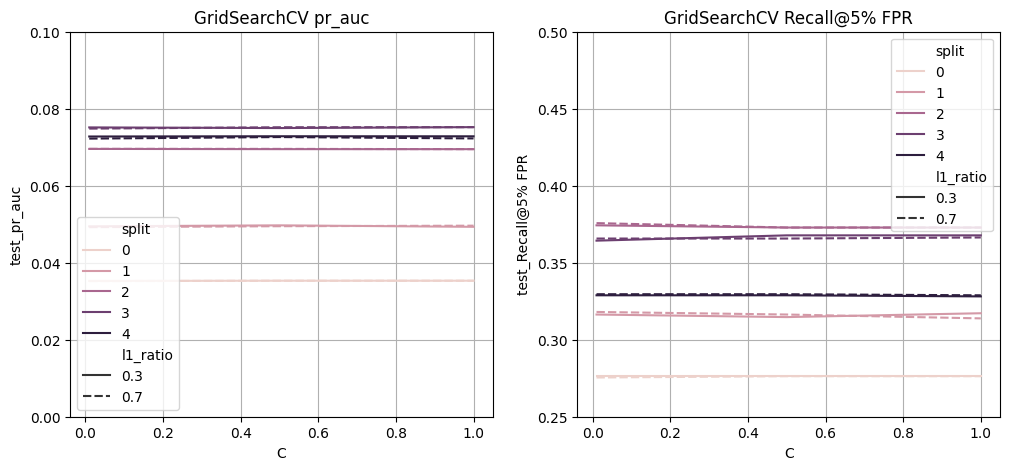

In [10]:
_res = gs_lr.cv_results_
_cv = cv_base

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_C'][i], _res['param_l1_ratio'][i], _res[f'split{j}_test_pr_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['C', 'l1_ratio', 'test_pr_auc', 'test_Recall@5% FPR', 'split'])

lr_base_res, lr_base_res_axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.lineplot(data=_df, x='C', y='test_pr_auc', ax=lr_base_res_axes[0], hue='split', style='l1_ratio')
sns.lineplot(data=_df, x='C', y='test_Recall@5% FPR', ax=lr_base_res_axes[1], hue='split', style='l1_ratio')

lr_base_res_axes[0].set_ylim((0, 0.1))
lr_base_res_axes[1].set_ylim((0.25, 0.5))

lr_base_res_axes[0].grid(True)
lr_base_res_axes[1].grid(True)

lr_base_res_axes[0].set_title('GridSearchCV pr_auc')
lr_base_res_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

Chosen best parameters: l1_ratio=0.7, C=0.01.

G:\PycharmProjects\FraudDetection\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


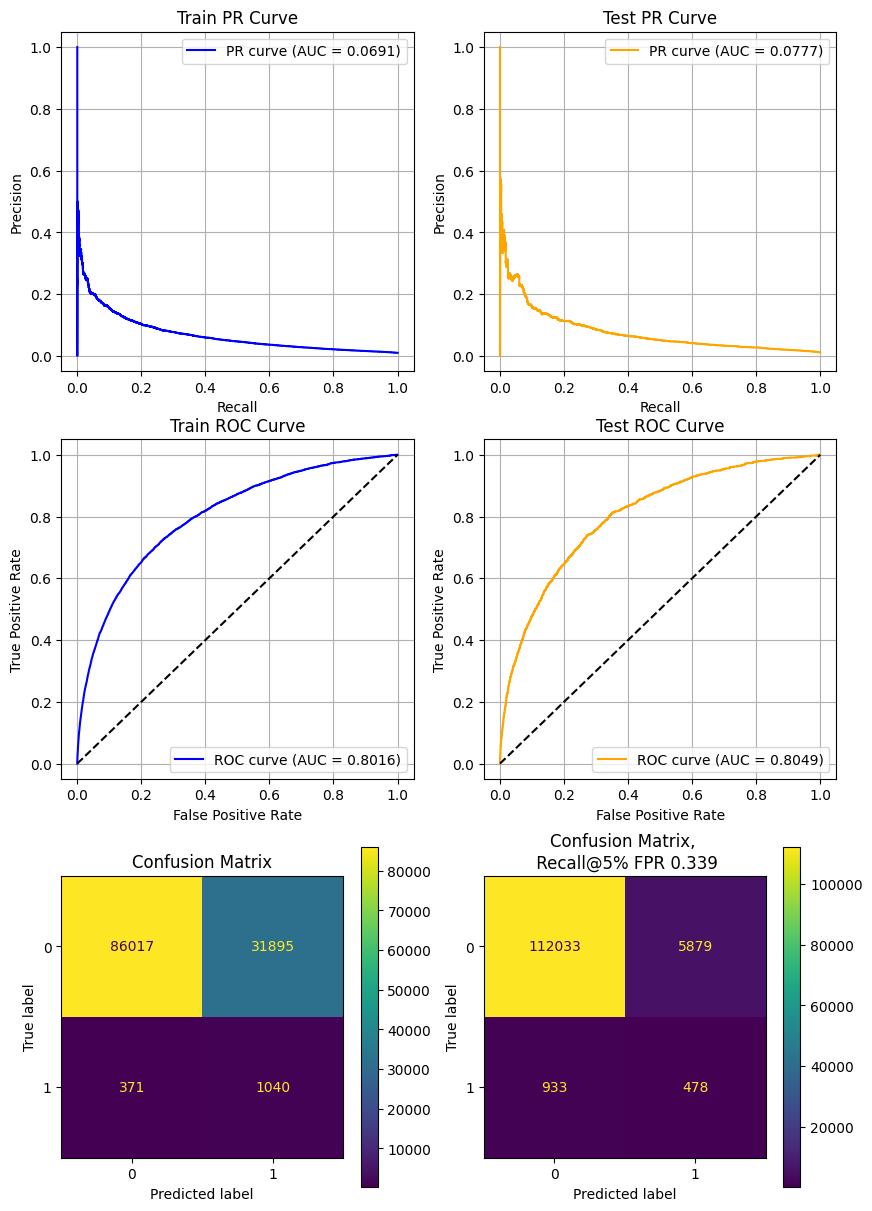

CPU times: total: 59.5 s
Wall time: 1min 4s


In [11]:
%%time

pipe_lr = Pipeline([
    ('preprocessor', dp_base),
    ('model', LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.7, C=0.01, class_weight='balanced', random_state=42,  n_jobs=-1, max_iter=200)),
])

pipe_lr.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

fig_lr, axes_lr = model_report(
    pipe_lr,
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

The model turned out to be quite weak

## Support Vector Machine Classifier

LiniarSVC has fewer options to tune. Parameter is chosen class_weight='balanced' to hadle the imbalanced class 

GridSearchCV will be performed on the parameter C (regularization strength)

LinearSVC does not return probabilities - only confidence scores for samples with decision_function

In [12]:
%%time

svc = LinearSVC(class_weight='balanced', random_state=42)

Cs = [0.01, 0.1, 1, 3]

gs_svc = GridSearchCV(
    svc, 
    param_grid={'C': Cs},
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    refit='Recall@5% FPR',
    n_jobs=-1, 
    cv=cv_base,
    return_train_score=True
)

gs_svc.fit(X_base, y_base)

CPU times: total: 1min 25s
Wall time: 3min 10s


GridSearchCV(cv=[(RangeIndex(start=0, stop=132440, step=1),
                  RangeIndex(start=132440, stop=260060, step=1)),
                 (RangeIndex(start=260060, stop=520120, step=1),
                  RangeIndex(start=520120, stop=657099, step=1)),
                 (RangeIndex(start=657099, stop=1054138, step=1),
                  RangeIndex(start=1054138, stop=1205074, step=1)),
                 (RangeIndex(start=1205074, stop=1753049, step=1),
                  RangeIndex(start=1...
                  RangeIndex(start=2556406, stop=2675729, step=1))],
             estimator=LinearSVC(class_weight='balanced', random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 3]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'})

In [13]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_svc.cv_results_)
_res_df['test_Recall_score'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_pr_auc_score'] = _res_df['mean_test_pr_auc'] - _res_df['std_test_pr_auc'] * 0.75
_res_df['test_roc_auc_score'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75


_res_df = _res_df.sort_values(by='test_Recall_score', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_score',
     'mean_train_pr_auc', 'mean_test_pr_auc', 'std_test_pr_auc', 'test_pr_auc_score',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_score',
     ]
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_score,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,test_pr_auc_score,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_score
2,{'C': 1},0.477443,0.505916,0.015264,0.494468,0.118682,0.131425,0.019843,0.116543,0.862016,0.877772,0.012252,0.868583
3,{'C': 3},0.477157,0.504751,0.016457,0.492408,0.118571,0.131421,0.019768,0.116595,0.862069,0.877895,0.012137,0.868792
1,{'C': 0.1},0.472026,0.503549,0.016824,0.490931,0.118106,0.130306,0.021018,0.114543,0.859730,0.875490,0.013611,0.865282
0,{'C': 0.01},0.428720,0.456779,0.035503,0.430152,0.103282,0.114406,0.027449,0.093819,0.838749,0.856328,0.020749,0.840767


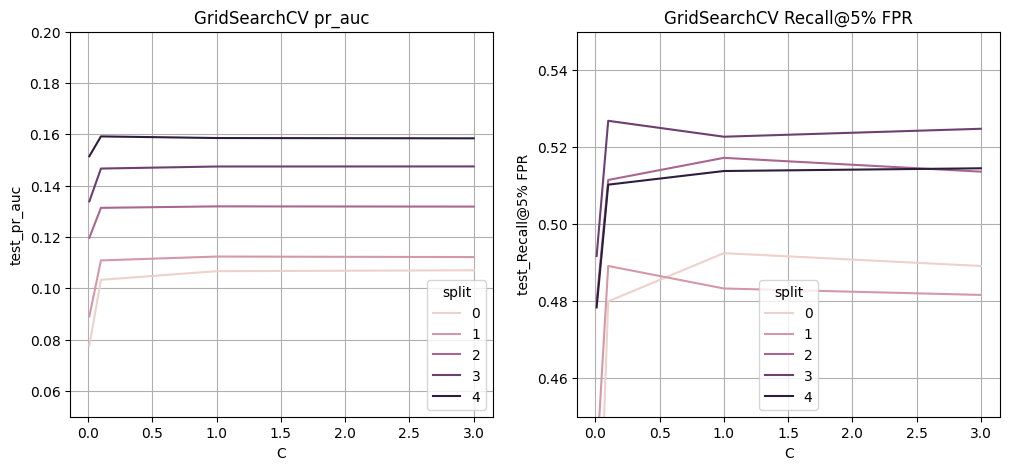

In [14]:
_res = gs_svc.cv_results_
_cv = cv_base

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_C'][i], _res[f'split{j}_test_pr_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['C', 'test_pr_auc', 'test_Recall@5% FPR', 'split'])

svc_base_res, svc_base_res_axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.lineplot(data=_df, x='C', y='test_pr_auc', ax=svc_base_res_axes[0], hue='split')
sns.lineplot(data=_df, x='C', y='test_Recall@5% FPR', ax=svc_base_res_axes[1], hue='split')

svc_base_res_axes[0].set_ylim((0.05, 0.2))
svc_base_res_axes[1].set_ylim((0.45, 0.55))

svc_base_res_axes[0].grid(True)
svc_base_res_axes[1].grid(True)

svc_base_res_axes[0].set_title('GridSearchCV pr_auc')
svc_base_res_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

The parameter C does not have a strong influence on the metric values starting from 0.1. The best scores are achieved by the model with C=1, so I will use this parameter

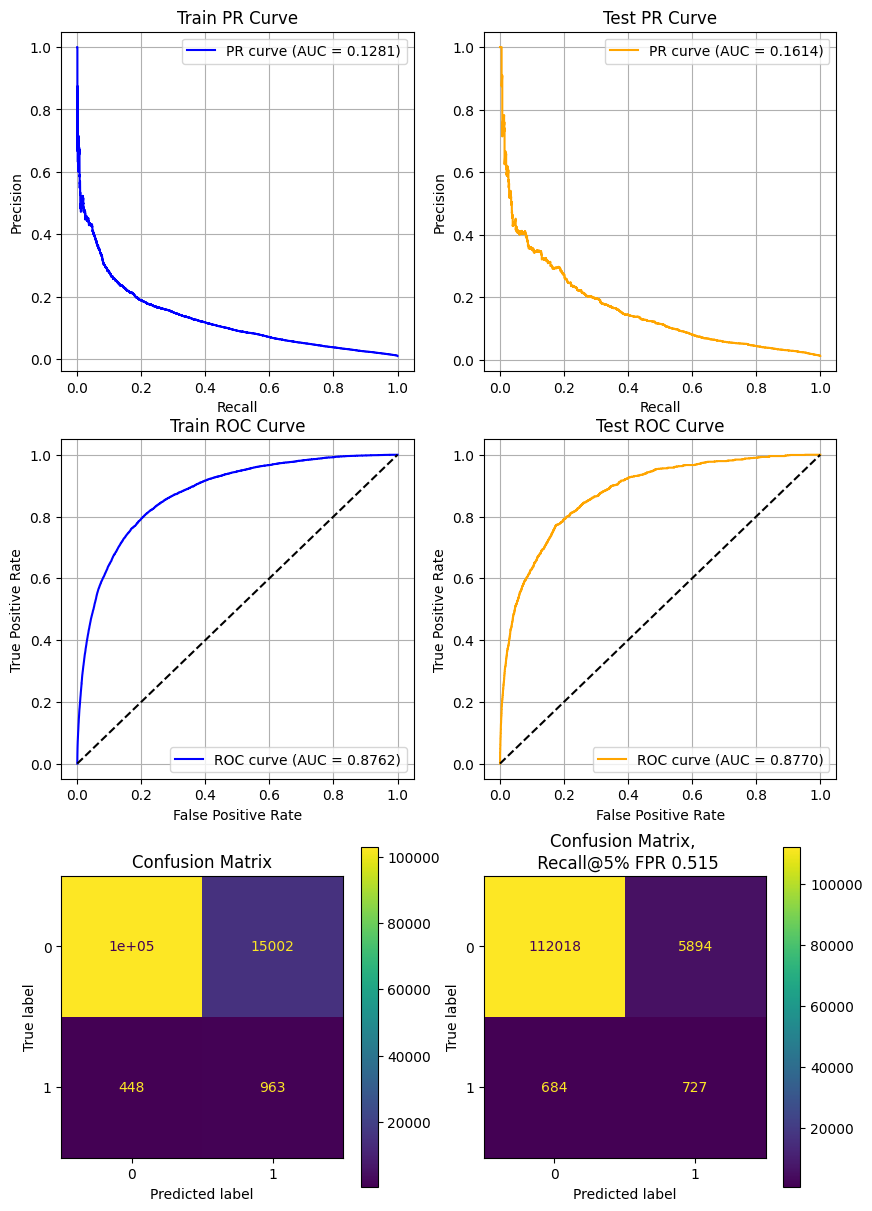

CPU times: total: 22.5 s
Wall time: 24.8 s


In [15]:
%%time

pipe_svc = Pipeline([
    ('preprocessor', dp_base),
    ('model', LinearSVC(class_weight='balanced', random_state=42, C=1)),
])

pipe_svc.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

fig_svc, axes_svc = model_report(
    pipe_svc,
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

The scores of LinearSVC are much higher than those of the Logistic Regression model. Recall@5% FRP increased from 0.34 to 0.51

I will remove unnecessary dataframes

In [16]:
del X_base, y_base, cv_base

# Add new features

I will add some insights obtained from the EDA results: I will calculate the similarity of applicants grouped by their age, income, device, and housing status. I will also add Isolation Forest scores

## Preprocessing

In [17]:
%%time

custom_funcs = (
    ('similarity', ('device_os', ['customer_age', 'income'])),
    ('similarity', ('housing_status', ['customer_age', 'income'])),
)


dp = DataPreprocessor(
    cat_features=[
        'email_is_free', 'has_other_cards',  'keep_alive_session', 'phone_home_valid',  'phone_mobile_valid', 'device_os',
        'employment_status', 'customer_age', 'payment_type',  'housing_status', 'foreign_request',  'income', 'device_distinct_emails_8w',
        'proposed_credit_limit',
    ],
    num_features=[
        'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 
        'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'session_length_in_minutes', 'days_since_request', 
        'velocity_6h', 'velocity_24h', 'velocity_4w',
    ],
    custom_functions=custom_funcs,
    num_ohe_mte_threshold=5
)


preprocessor = Pipeline([
    ('none_handler', NoneHandler()),
    ('handler', DataHandler()),
    ('data_preprocessor', dp),
    ('iso', IsoForest(contamination='auto')),
])

X_cv_nf, y_cv_nf, cv_nf = preprocess(preprocessor, X_train, y_train)

s 2025-10-21 15:17:04.815986
Month 0 ended at 2025-10-21 15:17:08.590704, total 3 seconds
Month 1 ended at 2025-10-21 15:17:14.664161, total 6 seconds
Month 2 ended at 2025-10-21 15:17:22.897472, total 8 seconds
Month 3 ended at 2025-10-21 15:17:33.014961, total 10 seconds
Month 4 ended at 2025-10-21 15:17:45.158176, total 12 seconds

There are some Na values!!!

Columns with Na:
device_os_linux
device_os_other

CPU times: total: 36.6 s
Wall time: 40.6 s


There was a discrepancy because I combined the output dataframes of different preprocessors. Their results may differ slightly. I will fix this manually now to eliminate the empty column. This does not affect the cross-validation result and such problems will not occur during a normal model run.

In [18]:
X_cv_nf.loc[(X_cv_nf.device_os_linux.isna()) & (X_cv_nf.device_os_other==0), 'device_os_linux'] = 1
X_cv_nf.loc[(X_cv_nf.device_os_linux.isna()) & (X_cv_nf.device_os_other==1), 'device_os_linux'] = 0
X_cv_nf = X_cv_nf.drop('device_os_other', axis=1)

## Random Forest

### Random Forest preprocessting

RandomForest involves training a large number of deep overfitted trees on bootstrap subsets. Training a large number of deep trees is very resource intensive. I will reduce the size of the training set by 2 times to speed up the process

In [19]:
%%time

list_df = []

for m in np.sort(X_train.month.unique()):
    _X_small, _, _, _ = train_test_split(
        X_train.loc[X_train.month==m], y_train.loc[X_train.month==m],
        train_size=0.5,
        stratify=y_train.loc[X_train.month==m],
        random_state=42
    )
    list_df.append(_X_small)

X_small = pd.concat(list_df, axis=0)
y_small = y_train.loc[X_small.index]

del _X_small, list_df, _    

X_cv_small, y_cv_small, cv_small = preprocess(preprocessor, X_small, y_small, return_transformers=False)

s 2025-10-21 15:17:46.098782
Month 0 ended at 2025-10-21 15:17:48.154387, total 2 seconds
Month 1 ended at 2025-10-21 15:17:51.029601, total 2 seconds
Month 2 ended at 2025-10-21 15:17:55.251303, total 4 seconds
Month 3 ended at 2025-10-21 15:18:00.532647, total 5 seconds
Month 4 ended at 2025-10-21 15:18:06.935460, total 6 seconds

There are some Na values!!!

Columns with Na:
device_os_linux
device_os_other

CPU times: total: 18 s
Wall time: 21.4 s


There was a discrepancy because I combined the output dataframes of different preprocessors. Their results may differ slightly. I will fix this manually now to eliminate the empty column. This does not affect the cross-validation result and such problems will not occur during a normal model run.

In [20]:
X_cv_small.loc[(X_cv_small.device_os_linux.isna()) & (X_cv_small.device_os_other==0), 'device_os_linux'] = 1
X_cv_small.loc[(X_cv_small.device_os_linux.isna()) & (X_cv_small.device_os_other==1), 'device_os_linux'] = 0
X_cv_small = X_cv_small.drop('device_os_other', axis=1)

### Tuning

Decision trees have many parameters to tune. Random forest inherits them. First, I'll check how the score changes when max_depth increases

Parameter class_weight='balanced_subsample' to handle the imbalanced target classes

In [21]:
%%time

forest_small = RandomForestClassifier(
    class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
    min_samples_leaf=1e-5,  min_impurity_decrease=5e-5, min_samples_split=5e-5, n_estimators=150,
)

max_depth = [35, 25, 20, 15, 10]

gs_forest_small = GridSearchCV(
    forest_small, 
    param_grid={'max_depth': max_depth},
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    refit='Recall@5% FPR',    
    n_jobs=-1, 
    cv=cv_small,
    return_train_score=True,
)

gs_forest_small.fit(X_cv_small, y_cv_small)

CPU times: total: 13min 36s
Wall time: 4min 35s


GridSearchCV(cv=[(RangeIndex(start=0, stop=66220, step=1),
                  RangeIndex(start=66220, stop=130030, step=1)),
                 (RangeIndex(start=130030, stop=260060, step=1),
                  RangeIndex(start=260060, stop=328549, step=1)),
                 (RangeIndex(start=328549, stop=527068, step=1),
                  RangeIndex(start=527068, stop=602536, step=1)),
                 (RangeIndex(start=602536, stop=876523, step=1),
                  RangeIndex(start=876523, s...
                                              min_samples_leaf=1e-05,
                                              min_samples_split=5e-05,
                                              n_estimators=150, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1, param_grid={'max_depth': [35, 25, 20, 15, 10]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'})

In [22]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_forest_small.cv_results_)
_res_df['test_Recall_score'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_pr_auc_score'] = _res_df['mean_test_pr_auc'] - _res_df['std_test_pr_auc'] * 0.75
_res_df['test_roc_auc_score'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75


_res_df = _res_df.sort_values(by='test_Recall_score', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_score',
     'mean_train_pr_auc', 'mean_test_pr_auc', 'std_test_pr_auc', 'test_pr_auc_score',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_score',
     ]
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_score,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,test_pr_auc_score,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_score
1,{'max_depth': 25},1.000000,0.493956,0.015568,0.482279,0.928203,0.114282,0.016970,0.101555,0.999449,0.869037,0.022922,0.851845
0,{'max_depth': 35},1.000000,0.495834,0.022938,0.478631,0.930247,0.113945,0.018518,0.100056,0.999470,0.869971,0.023461,0.852375
2,{'max_depth': 20},1.000000,0.481898,0.021777,0.465565,0.908415,0.109587,0.018351,0.095824,0.999237,0.868341,0.020523,0.852949
4,{'max_depth': 10},0.786359,0.473478,0.018719,0.459438,0.363545,0.102017,0.015989,0.090025,0.961701,0.871807,0.018844,0.857674
3,{'max_depth': 15},0.997426,0.455436,0.025275,0.436480,0.771888,0.099423,0.018555,0.085506,0.996583,0.864066,0.019867,0.849166


With the given parameters, the model cannot perfectly fit the training set even at max_depth = 35 (the PR-AUC is not equal to 1 but is close to it). The model with max_depth = 10 is clearly underfitted. Increasing the tree depth beyond 20–25 does not make sense, as other stopping criteria start to take effect and the metric values no longer improve significantly

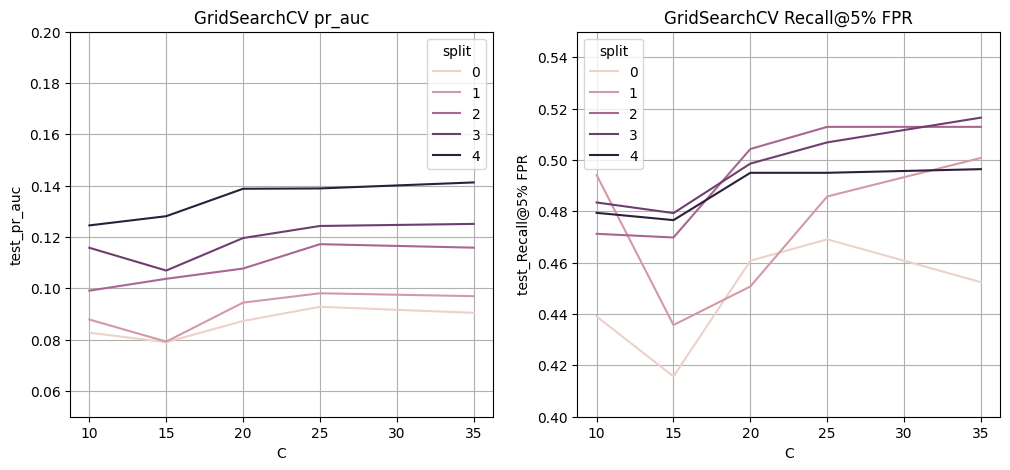

In [23]:
_res = gs_forest_small.cv_results_
_cv = cv_small

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_max_depth'][i], _res[f'split{j}_test_pr_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['C', 'test_pr_auc', 'test_Recall@5% FPR', 'split'])

svc_base_res, svc_base_res_axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.lineplot(data=_df, x='C', y='test_pr_auc', ax=svc_base_res_axes[0], hue='split')
sns.lineplot(data=_df, x='C', y='test_Recall@5% FPR', ax=svc_base_res_axes[1], hue='split')

svc_base_res_axes[0].set_ylim((0.05, 0.2))
svc_base_res_axes[1].set_ylim((0.4, 0.55))

svc_base_res_axes[0].grid(True)
svc_base_res_axes[1].grid(True)

svc_base_res_axes[0].set_title('GridSearchCV pr_auc')
svc_base_res_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

I will choose max_depth=25 as the optimal value

In [24]:
%%time

forest_small_1 = RandomForestClassifier(
    class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
    min_impurity_decrease=5e-5, n_estimators=150, max_depth=25
)


min_samples_leaf = [1e-5, 5e-4, 1e-4]
min_samples_split = [5e-5, 5e-4]

gs_forest_small_1 = GridSearchCV(
    forest_small_1, 
    param_grid={'min_samples_leaf': min_samples_leaf, 'min_samples_split': min_samples_split},
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    refit='Recall@5% FPR',    
    n_jobs=-1, 
    cv=cv_small,
    return_train_score=True,
)

gs_forest_small_1.fit(X_cv_small, y_cv_small)

CPU times: total: 12min 4s
Wall time: 5min 10s


GridSearchCV(cv=[(RangeIndex(start=0, stop=66220, step=1),
                  RangeIndex(start=66220, stop=130030, step=1)),
                 (RangeIndex(start=130030, stop=260060, step=1),
                  RangeIndex(start=260060, stop=328549, step=1)),
                 (RangeIndex(start=328549, stop=527068, step=1),
                  RangeIndex(start=527068, stop=602536, step=1)),
                 (RangeIndex(start=602536, stop=876523, step=1),
                  RangeIndex(start=876523, s...
                                              n_estimators=150, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'min_samples_leaf': [1e-05, 0.0005, 0.0001],
                         'min_samples_split': [5e-05, 0.0005]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'})

It has been possible to increase scores a little on the test

In [25]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_forest_small_1.cv_results_)
_res_df['test_Recall_score'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_pr_auc_score'] = _res_df['mean_test_pr_auc'] - _res_df['std_test_pr_auc'] * 0.75
_res_df['test_roc_auc_score'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75


_res_df = _res_df.sort_values(by='test_Recall_score', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_score',
     'mean_train_pr_auc', 'mean_test_pr_auc', 'std_test_pr_auc', 'test_pr_auc_score',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_score',
     ]
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_score,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,test_pr_auc_score,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_score
2,"{'min_samples_leaf': 0.0005, 'min_samples_spli...",0.822465,0.502969,0.011187,0.494579,0.343736,0.119257,0.014530,0.108359,0.973322,0.879052,0.016198,0.866904
3,"{'min_samples_leaf': 0.0005, 'min_samples_spli...",0.822465,0.502969,0.011187,0.494579,0.343736,0.119257,0.014530,0.108359,0.973322,0.879052,0.016198,0.866904
1,"{'min_samples_leaf': 1e-05, 'min_samples_split...",0.997135,0.499741,0.014208,0.489085,0.679693,0.113017,0.016786,0.100427,0.994799,0.877455,0.016830,0.864832
4,"{'min_samples_leaf': 0.0001, 'min_samples_spli...",0.999763,0.500985,0.018005,0.487481,0.706830,0.120098,0.019190,0.105705,0.995757,0.876342,0.018946,0.862132
5,"{'min_samples_leaf': 0.0001, 'min_samples_spli...",0.983968,0.499106,0.019072,0.484802,0.600272,0.119174,0.018068,0.105623,0.992060,0.875656,0.018586,0.861716
0,"{'min_samples_leaf': 1e-05, 'min_samples_split...",1.000000,0.493956,0.015568,0.482279,0.928203,0.114282,0.016970,0.101555,0.999449,0.869037,0.022922,0.851845


For now, I will select the parameters that showed the best results in cross-validation, despite the fact that the model is overfitted. In the next section, parameter enumeration will be carried out using Optuna, where more attention will be paid to selecting the best parameters

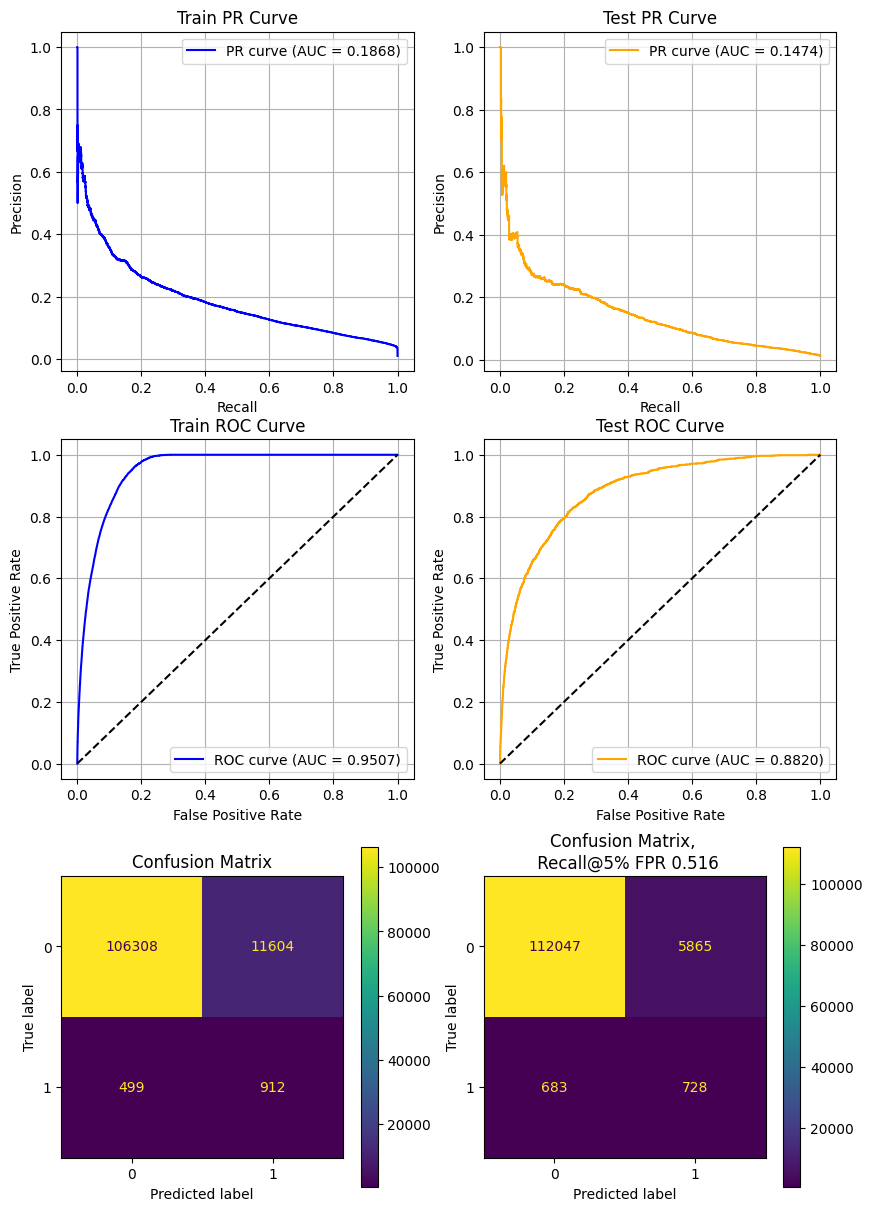

CPU times: total: 9min 44s
Wall time: 1min 10s


In [26]:
%%time

pipe_forest = Pipeline([
    ('dp', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
        min_impurity_decrease=5e-5, n_estimators=250, max_depth=25, min_samples_leaf=2.5e-4, min_samples_split = 5e-4,
    )),
])


pipe_forest.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

fig_forest, axes_forest = model_report(
    pipe_forest,
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

The performance of the resulting RandomForest model is slightly better than that of LinearSVC

## XGBoost

XGBoost is based on training a large number of shallow decision trees that correct each other’s errors

To begin with, I will focus on the max_depth and n_estimators parameters

All other parameters are fixed. The negative-to-positive class ratio in the entire training set is passed to the scale_pos_weight parameter

In [27]:
%%time

xgb_params_gs = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'learning_rate': 0.1,
    'subsample': 0.9,
    'colsample_bytree': 0.5, 
    'min_child_weight': 0.05, 
    'gamma': 0.1,
    'reg_alpha': 0.75,
    'reg_lambda': 1e-3,
    'eval_metric': 'logloss'
}

xgb_gs = XGBClassifier(**xgb_params_gs)


n_estimators = [200, 350, 600, 800, 1000]
max_depth = [1, 2, 5]


gs_xgb = GridSearchCV(
    xgb_gs, 
    param_grid={'n_estimators': n_estimators, 'max_depth': max_depth},
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    refit='Recall@5% FPR', 
    n_jobs=-1, 
    cv=cv_nf,
    return_train_score=True
)

gs_xgb.fit(X_cv_nf, y_cv_nf)

CPU times: total: 3min 19s
Wall time: 3min 56s


GridSearchCV(cv=[(RangeIndex(start=0, stop=132440, step=1),
                  RangeIndex(start=132440, stop=260060, step=1)),
                 (RangeIndex(start=260060, stop=520120, step=1),
                  RangeIndex(start=520120, stop=657099, step=1)),
                 (RangeIndex(start=657099, stop=1054138, step=1),
                  RangeIndex(start=1054138, stop=1205074, step=1)),
                 (RangeIndex(start=1205074, stop=1753049, step=1),
                  RangeIndex(start=1...
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2, 5],
                         'n_estimators': [200, 350, 600, 800, 1000]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'})

In [28]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_xgb.cv_results_)
_res_df['test_Recall_score'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_pr_auc_score'] = _res_df['mean_test_pr_auc'] - _res_df['std_test_pr_auc'] * 0.75
_res_df['test_roc_auc_score'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_score', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_score',
     'mean_train_pr_auc', 'mean_test_pr_auc', 'std_test_pr_auc', 'test_pr_auc_score',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_score',
     ]
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_score,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,test_pr_auc_score,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_score
4,"{'max_depth': 1, 'n_estimators': 1000}",0.538742,0.553089,0.020497,0.537716,0.152905,0.159848,0.026107,0.140268,0.892385,0.897042,0.012459,0.887697
3,"{'max_depth': 1, 'n_estimators': 800}",0.538149,0.552734,0.020556,0.537317,0.151991,0.159260,0.025434,0.140185,0.890880,0.896607,0.012464,0.887259
2,"{'max_depth': 1, 'n_estimators': 600}",0.533483,0.552318,0.020024,0.537300,0.150171,0.158309,0.023811,0.140450,0.888753,0.896074,0.012175,0.886943
6,"{'max_depth': 2, 'n_estimators': 350}",0.552967,0.550817,0.022250,0.534129,0.160358,0.159233,0.026069,0.139681,0.900924,0.896026,0.013660,0.885781
7,"{'max_depth': 2, 'n_estimators': 600}",0.565257,0.553437,0.026272,0.533733,0.165791,0.158560,0.027656,0.137819,0.910181,0.895527,0.014718,0.884488
1,"{'max_depth': 1, 'n_estimators': 350}",0.518391,0.540721,0.015691,0.528953,0.143861,0.153672,0.020322,0.138430,0.884035,0.893579,0.011928,0.884633
5,"{'max_depth': 2, 'n_estimators': 200}",0.536840,0.545535,0.024048,0.527499,0.153394,0.155921,0.022923,0.138729,0.892381,0.894291,0.013207,0.884386
9,"{'max_depth': 2, 'n_estimators': 1000}",0.580766,0.546296,0.027968,0.525321,0.171199,0.157128,0.028413,0.135818,0.920245,0.893703,0.015392,0.882159
8,"{'max_depth': 2, 'n_estimators': 800}",0.574363,0.547560,0.030175,0.524928,0.168920,0.157690,0.027978,0.136706,0.915712,0.894655,0.014982,0.883419
0,"{'max_depth': 1, 'n_estimators': 200}",0.498088,0.519931,0.014574,0.509001,0.132612,0.143546,0.017299,0.130572,0.876743,0.888473,0.011678,0.879714


The score of XGBoost with max_depth = 1 and n_estimators = 1000 is better than the best score of RandomForest. The model is not overfitted, as the difference between the training and test scores is small

Shallow trees perform better than deeper ones. As the number of estimators increases, the score improves

Models with max_depth = 5 (especially with a large number of estimators) are overfitted

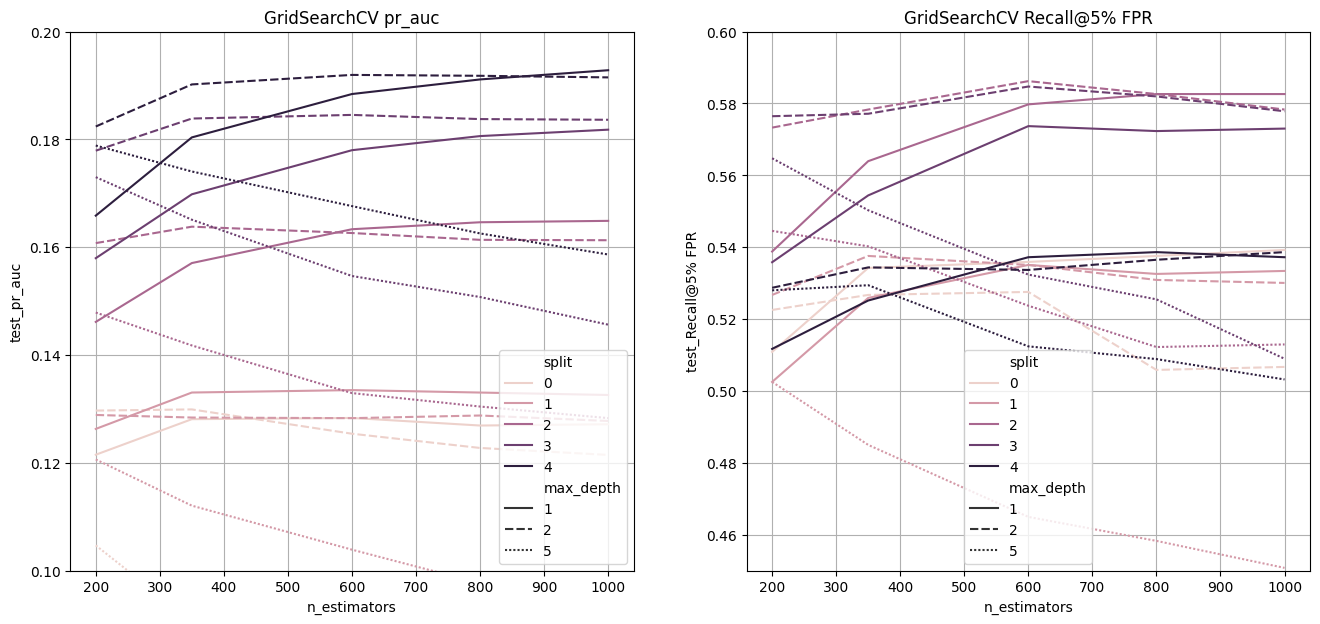

In [29]:
_res = gs_xgb.cv_results_
_cv = cv_nf

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_n_estimators'][i], _res['param_max_depth'][i], _res[f'split{j}_test_pr_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['n_estimators', 'max_depth', 'test_pr_auc', 'test_Recall@5% FPR', 'split'])

xgb_res, xgb_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

sns.lineplot(data=_df, x='n_estimators', y='test_pr_auc', ax=xgb_axes[0], hue='split', style='max_depth')
sns.lineplot(data=_df, x='n_estimators', y='test_Recall@5% FPR', ax=xgb_axes[1], hue='split', style='max_depth')

xgb_axes[0].set_ylim((0.1, 0.2))
xgb_axes[1].set_ylim((0.45, 0.6))

xgb_axes[0].grid(True)
xgb_axes[1].grid(True)

xgb_axes[0].set_title('GridSearchCV pr_auc')
xgb_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

Train the model with the best parameters

In [30]:
%%time

xgb_params = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'n_estimators': 1000,
    'max_depth': 1,
    'learning_rate': 0.1,
    'subsample': 0.9,
    'colsample_bytree': 0.5, 
    'min_child_weight': 0.05, 
    'gamma': 0.1,
    'reg_alpha': 0.75,
    'reg_lambda': 1e-3,
    'eval_metric': 'logloss',
    'seed': 42,    
}

xgb = XGBClassifier(**xgb_params)


pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb),
])

pipe_xgb.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

CPU times: total: 1min 23s
Wall time: 17.7 s


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('none_handler', NoneHandler()),
                                 ('handler', DataHandler()),
                                 ('data_preprocessor',
                                  DataPreprocessor(cat_features=['email_is_free',
                                                                 'has_other_cards',
                                                                 'keep_alive_session',
                                                                 'phone_home_valid',
                                                                 'phone_mobile_valid',
                                                                 'device_os',
                                                                 'employment_status',
                                                                 'customer_age',
                                                                 'payment_type',
                                                                 'housing_status',
                                                                 'foreign_request',
                                                                 '...
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=1, max_leaves=None,
                               min_child_weight=0.05, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=None,
                               num_parallel_tree=None, ...))])

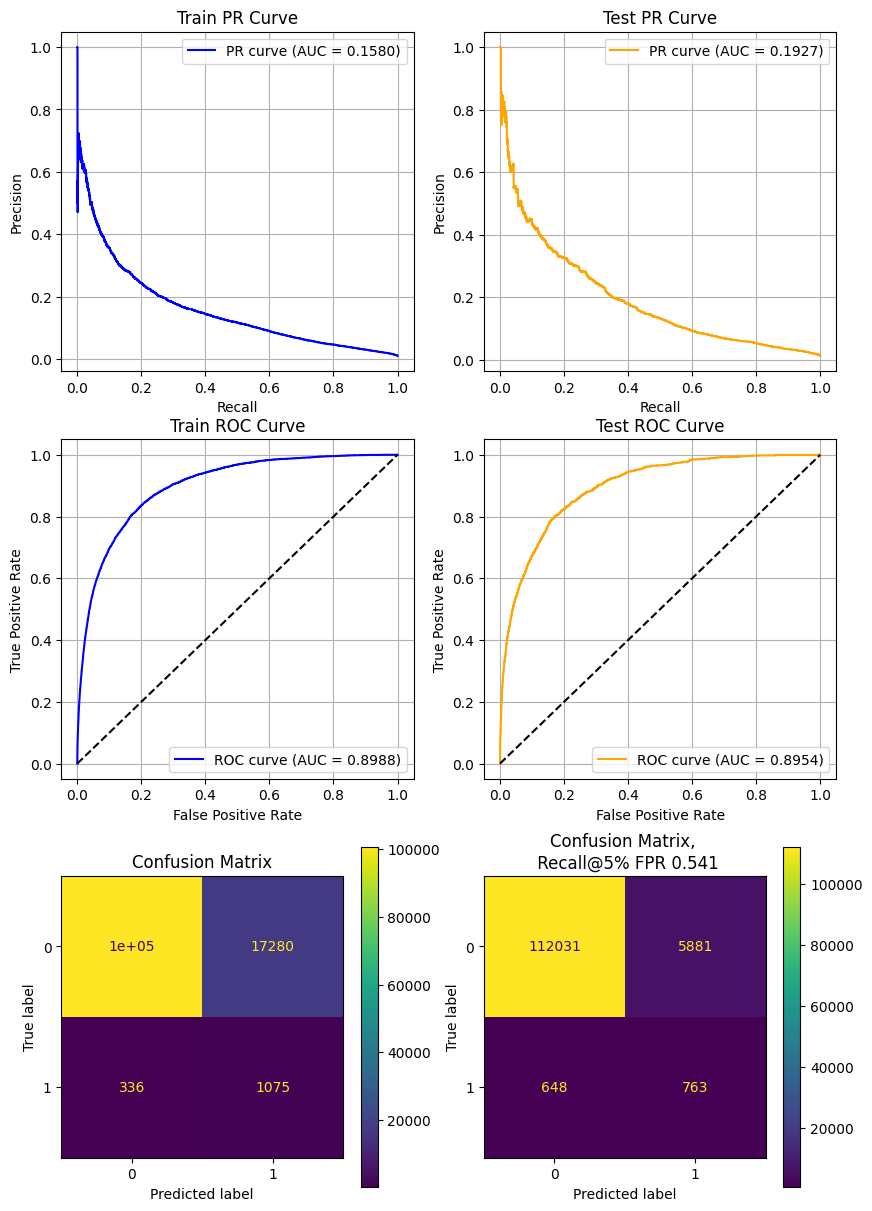

In [31]:
fig_xgb, axes_xgb = model_report(
    pipe_xgb, 
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)
plt.show()

The performance of the resulting XGBoost model is much better than that of RandomForest. Training and test scores are very close, so there is no overfitting

# Undersampling, oversampling (NearMiss & SMOTE)

The target class is highly imbalanced. I will try using methods from imbalanced-learn. I will create a small class to preprocess the data by removing some negative samples and adding some positive ones. It takes two parameters:

- final_pos_rate - the ratio of positive samples to all samples after the transformation
- synt_rate - the ratio of synthesized positive samples to all positive samples after the transformation

In [32]:
def imb_preprocess(X, y, cv=None, final_pos_rate=0.1, synt_rate=0.8):
    
    smote_strat = final_pos_rate / (1 - final_pos_rate)
    nm_strat = (1 - synt_rate) * smote_strat

    x_list = []
    y_list = []
    new_cv = []
    last_index = 0
    
    if cv is None:
        cv = ((X.index), (X.index))

    t = datetime.datetime.now()
    print('s', t)

    for i, split in enumerate(cv):

        nm = NearMiss(
            sampling_strategy=nm_strat, 
            n_jobs=-1,
        )
        smote = SMOTE(
            sampling_strategy=smote_strat, 
            random_state=42,
        )
        
        pipe_imb = ImbPipeline([
            ('nm', nm),
            ('smote', smote),
        ])

        _x, _y = pipe_imb.fit_resample(X.loc[split[0]], y.loc[split[0]])
        
        x_list.append(_x)
        y_list.append(_y)
        x_list.append(X.loc[split[1]])
        y_list.append(y.loc[split[1]])

        new_cv.append(
            (
                pd.RangeIndex(start=last_index, stop=last_index+len(_x)), 
                pd.RangeIndex(start=last_index+len(_x), stop=last_index+len(_x)+len(X.loc[split[1]])),
            )
        )

        last_index = last_index+len(_x)+len(X.loc[split[1]])

        delta = int((datetime.datetime.now() - t).total_seconds())
        t = datetime.datetime.now()
        
        print(f"Split {i} ended at {t}, total {delta} seconds")
        

    X_transformed = pd.concat(x_list, axis=0, ignore_index=True)
    y_transformed = pd.concat(y_list, axis=0, ignore_index=True)

    return X_transformed, y_transformed, new_cv

The parameters must be in the acceptable range, and their combination will greatly affect the final size of the dataset

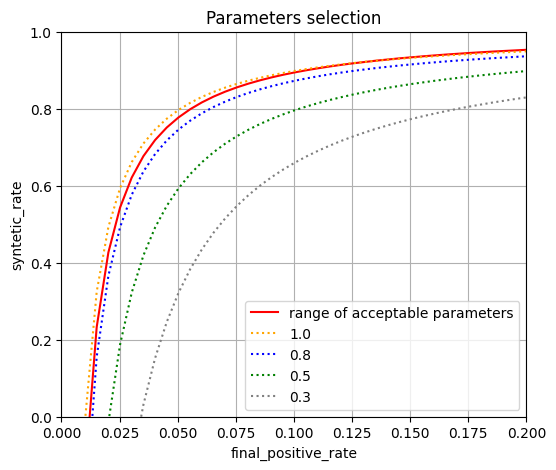

In [33]:
max_rate = 1e-3

for m in X_train.month.unique():
    if np.sum(y_train[X_train.month==m]) / np.sum(X_train.month==m) > max_rate:
        max_rate = np.sum(y_train[X_train.month==m]) / np.sum(X_train.month==m)

avg_rate = np.sum(y_train) / len(y_train)

fin_rates_ax = np.linspace(1e-4, 1-1e-4, 200)

plt.figure(figsize=(6,5))

sns.lineplot(x=fin_rates_ax, y=(1 + max_rate - max_rate / fin_rates_ax), linestyle='-', color='r', label='range of acceptable parameters')
sns.lineplot(x=fin_rates_ax, y=(1 - avg_rate / fin_rates_ax), linestyle=':', color='orange', label='1.0')
sns.lineplot(x=fin_rates_ax, y=(1 - avg_rate / fin_rates_ax / 0.8),  linestyle=':', color='b', label='0.8')
sns.lineplot(x=fin_rates_ax, y=(1 - avg_rate / fin_rates_ax / 0.5),  linestyle=':', color='g', label='0.5')
sns.lineplot(x=fin_rates_ax, y=(1 - avg_rate / fin_rates_ax / 0.3),  linestyle=':', color='gray', label='0.3')

plt.xlabel('final_positive_rate')
plt.ylabel('syntetic_rate')

plt.xlim((0, 0.2))
plt.ylim((0, 1))
plt.grid(True)
plt.legend()
plt.title('Parameters selection')

plt.show()

In [34]:
final_pos_rate=0.1
synt_rate=0.8

print(f"When using imbalanced learning with parameters: final_pos_rate={final_pos_rate} and synt_rate={synt_rate}, the train part will be {(np.sum(y_train) / len(y_train) / final_pos_rate / (1 - synt_rate)):.1%} of the original")

When using imbalanced learning with parameters: final_pos_rate=0.1 and synt_rate=0.8, the train part will be 51.3% of the original


In [83]:
%%time
X_imb, y_imb, cv_imb = imb_preprocess(X_cv_nf, y_cv_nf, cv=cv_nf, final_pos_rate=0.1, synt_rate=0.8)

s 2025-10-21 16:45:55.936773
Split 0 ended at 2025-10-21 16:45:56.312054, total 0 seconds
Split 1 ended at 2025-10-21 16:45:57.139545, total 0 seconds
Split 2 ended at 2025-10-21 16:45:58.493879, total 1 seconds
Split 3 ended at 2025-10-21 16:46:00.661468, total 2 seconds
Split 4 ended at 2025-10-21 16:46:03.719626, total 3 seconds
CPU times: total: 1min 5s
Wall time: 7.93 s


I will strengthen the regularization to prevent overfitting

In [36]:
%%time

imb_xgb_params_gs = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'learning_rate': 0.1,
    'subsample': 0.6,
    'colsample_bytree': 0.4, 
    'min_child_weight': 0.05, 
    'gamma': 0.4,
    'reg_alpha': 0.2,
    'reg_lambda': 0.2,
    'eval_metric': 'logloss',
    'seed': 42,
}

imb_xgb = XGBClassifier(**imb_xgb_params_gs)


n_estimators = [50, 100, 300, 600]
max_depth = [1, 2]


imb_gs_xgb = GridSearchCV(
    imb_xgb, 
    param_grid={'n_estimators': n_estimators, 'max_depth': max_depth},
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    refit='Recall@5% FPR', 
    n_jobs=-1, 
    cv=cv_imb,
    return_train_score=True
)

imb_gs_xgb.fit(X_imb, y_imb)

CPU times: total: 38.7 s
Wall time: 46.6 s


GridSearchCV(cv=[(RangeIndex(start=0, stop=75000, step=1),
                  RangeIndex(start=75000, stop=202620, step=1)),
                 (RangeIndex(start=202620, stop=337520, step=1),
                  RangeIndex(start=337520, stop=474499, step=1)),
                 (RangeIndex(start=474499, stop=669299, step=1),
                  RangeIndex(start=669299, stop=820235, step=1)),
                 (RangeIndex(start=820235, stop=1084635, step=1),
                  RangeIndex(start=1084635...
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2],
                         'n_estimators': [50, 100, 300, 600]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'})

In [37]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(imb_gs_xgb.cv_results_)
_res_df['test_Recall_score'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_pr_auc_score'] = _res_df['mean_test_pr_auc'] - _res_df['std_test_pr_auc'] * 0.75
_res_df['test_roc_auc_score'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_score', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_score',
     'mean_train_pr_auc', 'mean_test_pr_auc', 'std_test_pr_auc', 'test_pr_auc_score',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_score',
     ]
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_score,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,test_pr_auc_score,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_score
1,"{'max_depth': 1, 'n_estimators': 100}",0.683367,0.429356,0.022241,0.412675,0.699170,0.086712,0.015624,0.074994,0.930425,0.853578,0.012697,0.844055
0,"{'max_depth': 1, 'n_estimators': 50}",0.614077,0.417774,0.012800,0.408174,0.619797,0.079336,0.010183,0.071698,0.912418,0.846025,0.013349,0.836013
4,"{'max_depth': 2, 'n_estimators': 50}",0.759537,0.414447,0.022412,0.397638,0.802873,0.080112,0.011999,0.071113,0.945849,0.848757,0.012952,0.839043
2,"{'max_depth': 1, 'n_estimators': 300}",0.779543,0.347265,0.040993,0.316520,0.795715,0.063704,0.016843,0.051072,0.952182,0.835066,0.013040,0.825286
5,"{'max_depth': 2, 'n_estimators': 100}",0.823127,0.349503,0.044376,0.316220,0.853679,0.060104,0.013860,0.049710,0.959858,0.835415,0.015319,0.823926
3,"{'max_depth': 1, 'n_estimators': 600}",0.833697,0.292465,0.041462,0.261369,0.850452,0.051657,0.012145,0.042548,0.963685,0.823146,0.013900,0.812721
6,"{'max_depth': 2, 'n_estimators': 300}",0.891097,0.214830,0.040118,0.184741,0.910688,0.036617,0.008930,0.029919,0.975318,0.805871,0.017668,0.792620
7,"{'max_depth': 2, 'n_estimators': 600}",0.909422,0.175977,0.025212,0.157068,0.929485,0.031046,0.006891,0.025877,0.980655,0.791121,0.017797,0.777774


Starting from around 100 estimators, as their number and the tree depth increase, the model performance begins to decline due to overfitting on the training set

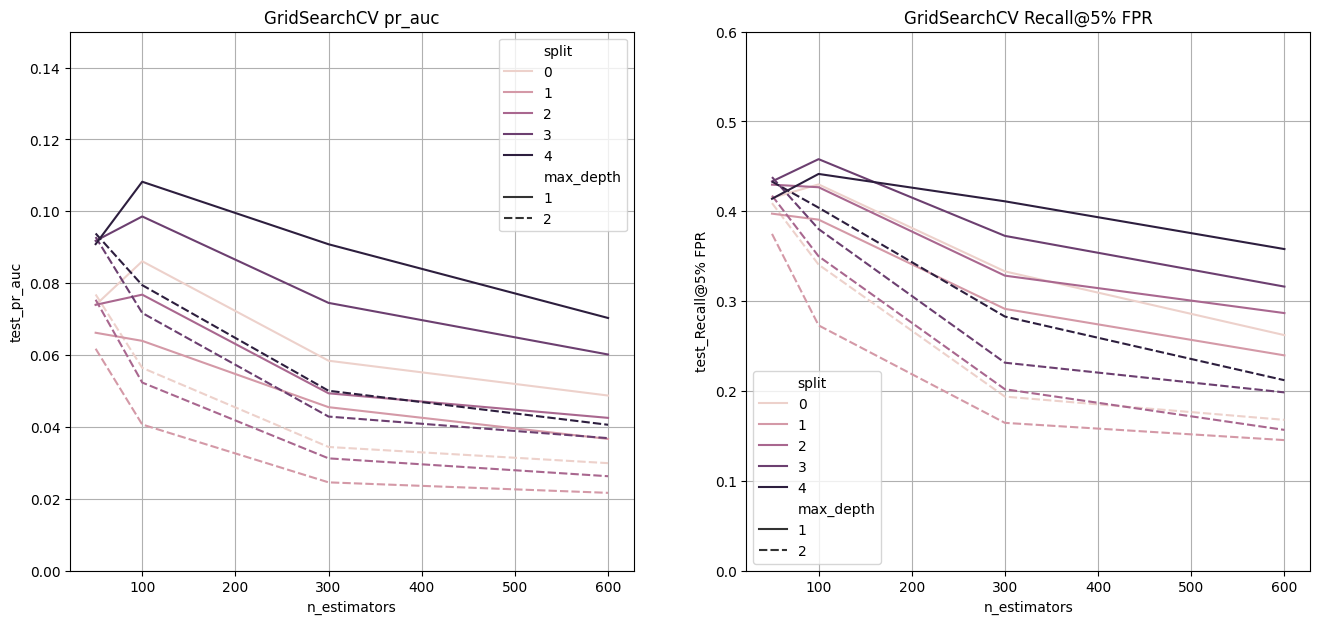

In [38]:
_res = imb_gs_xgb.cv_results_
_cv = cv_imb

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_n_estimators'][i], _res['param_max_depth'][i], _res[f'split{j}_test_pr_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['n_estimators', 'max_depth', 'test_pr_auc', 'test_Recall@5% FPR', 'split'])

imb_xgb_res, imb_xgb_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

sns.lineplot(data=_df, x='n_estimators', y='test_pr_auc', ax=imb_xgb_axes[0], hue='split', style='max_depth')
sns.lineplot(data=_df, x='n_estimators', y='test_Recall@5% FPR', ax=imb_xgb_axes[1], hue='split', style='max_depth')

imb_xgb_axes[0].set_ylim((0.0, 0.15))
imb_xgb_axes[1].set_ylim((0.0, 0.6))

imb_xgb_axes[0].grid(True)
imb_xgb_axes[1].grid(True)

imb_xgb_axes[0].set_title('GridSearchCV pr_auc')
imb_xgb_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

The obtained results are much lower than expected. This is due to the ease of overfitting, as the proportion of the minority class was significantly increased. I adjusted the resampling parameters to prevent overfitting

In [39]:
final_pos_rate=0.04
synt_rate=0.72

print(f"When using imbalanced learning with parameters: final_pos_rate={final_pos_rate} and synt_rate={synt_rate}, the train part will be {(np.sum(y_train) / len(y_train) / final_pos_rate / (1 - synt_rate)):.1%} of the original")

When using imbalanced learning with parameters: final_pos_rate=0.04 and synt_rate=0.72, the train part will be 91.5% of the original


In [40]:
%%time
X_imb, y_imb, cv_imb = imb_preprocess(X_cv_nf, y_cv_nf, cv=cv_nf, final_pos_rate=0.04, synt_rate=0.72)

s 2025-10-21 15:34:24.277959
Split 0 ended at 2025-10-21 15:34:24.708905, total 0 seconds
Split 1 ended at 2025-10-21 15:34:25.606281, total 0 seconds
Split 2 ended at 2025-10-21 15:34:27.081015, total 1 seconds
Split 3 ended at 2025-10-21 15:34:29.391987, total 2 seconds
Split 4 ended at 2025-10-21 15:34:32.739996, total 3 seconds
CPU times: total: 1min 6s
Wall time: 8.59 s


In [41]:
%%time

imb_xgb_params_gs_1 = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'learning_rate': 0.1,
    'subsample': 0.6,
    'colsample_bytree': 0.4, 
    'min_child_weight': 0.05, 
    'gamma': 0.4,
    'reg_alpha': 0.2,
    'reg_lambda': 0.2,
    'eval_metric': 'logloss',
    'seed': 42,
}

imb_xgb_1 = XGBClassifier(**imb_xgb_params_gs_1)


n_estimators = [100, 250, 400, 600, 800, 1000]
max_depth = [1, 2]


imb_gs_xgb_1 = GridSearchCV(
    imb_xgb_1, 
    param_grid={'n_estimators': n_estimators, 'max_depth': max_depth},
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    refit='Recall@5% FPR', 
    n_jobs=-1, 
    cv=cv_imb,
    return_train_score=True
)

imb_gs_xgb_1.fit(X_imb, y_imb)

CPU times: total: 7min 9s
Wall time: 3min 32s


GridSearchCV(cv=[(RangeIndex(start=0, stop=133928, step=1),
                  RangeIndex(start=133928, stop=261548, step=1)),
                 (RangeIndex(start=261548, stop=502440, step=1),
                  RangeIndex(start=502440, stop=639419, step=1)),
                 (RangeIndex(start=639419, stop=987275, step=1),
                  RangeIndex(start=987275, stop=1138211, step=1)),
                 (RangeIndex(start=1138211, stop=1610353, step=1),
                  RangeIndex(start=161...
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2],
                         'n_estimators': [100, 250, 400, 600, 800, 1000]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'})

The results became similar to those obtained without resampling. Shallow trees with max_depth = 1 and a very large number of estimators show the best performance. The model performance on the test set is close to that before resampling

In [42]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(imb_gs_xgb_1.cv_results_)
_res_df['test_Recall_score'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_pr_auc_score'] = _res_df['mean_test_pr_auc'] - _res_df['std_test_pr_auc'] * 0.75
_res_df['test_roc_auc_score'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_score', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_score',
     'mean_train_pr_auc', 'mean_test_pr_auc', 'std_test_pr_auc', 'test_pr_auc_score',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_score',
     ]
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_score,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,test_pr_auc_score,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_score
5,"{'max_depth': 1, 'n_estimators': 1000}",0.826424,0.528130,0.013091,0.518311,0.751795,0.138012,0.022449,0.121175,0.959840,0.886801,0.010807,0.878695
4,"{'max_depth': 1, 'n_estimators': 800}",0.815843,0.526199,0.011843,0.517317,0.732396,0.137593,0.021867,0.121193,0.957707,0.886330,0.010722,0.878288
3,"{'max_depth': 1, 'n_estimators': 600}",0.799272,0.520532,0.012089,0.511465,0.703419,0.135914,0.020412,0.120605,0.954465,0.884861,0.010699,0.876836
7,"{'max_depth': 2, 'n_estimators': 250}",0.846695,0.514044,0.012822,0.504427,0.810481,0.133837,0.024322,0.115595,0.964729,0.884645,0.010376,0.876863
2,"{'max_depth': 1, 'n_estimators': 400}",0.772657,0.514665,0.013877,0.504257,0.655950,0.133592,0.018492,0.119723,0.948912,0.883555,0.010635,0.875579
8,"{'max_depth': 2, 'n_estimators': 400}",0.859994,0.509885,0.010964,0.501662,0.829688,0.130044,0.024868,0.111393,0.968630,0.884922,0.010488,0.877056
9,"{'max_depth': 2, 'n_estimators': 600}",0.867373,0.505562,0.016090,0.493494,0.841980,0.125766,0.026514,0.105880,0.971654,0.884479,0.010810,0.876371
1,"{'max_depth': 1, 'n_estimators': 250}",0.737879,0.502032,0.013593,0.491838,0.594590,0.126967,0.017262,0.114020,0.941496,0.880372,0.010735,0.872320
10,"{'max_depth': 2, 'n_estimators': 800}",0.871798,0.500031,0.012897,0.490358,0.849650,0.118750,0.026030,0.099227,0.973818,0.883321,0.010577,0.875388
11,"{'max_depth': 2, 'n_estimators': 1000}",0.874462,0.494452,0.016676,0.481946,0.854046,0.112520,0.024798,0.093921,0.975412,0.881559,0.011023,0.873292


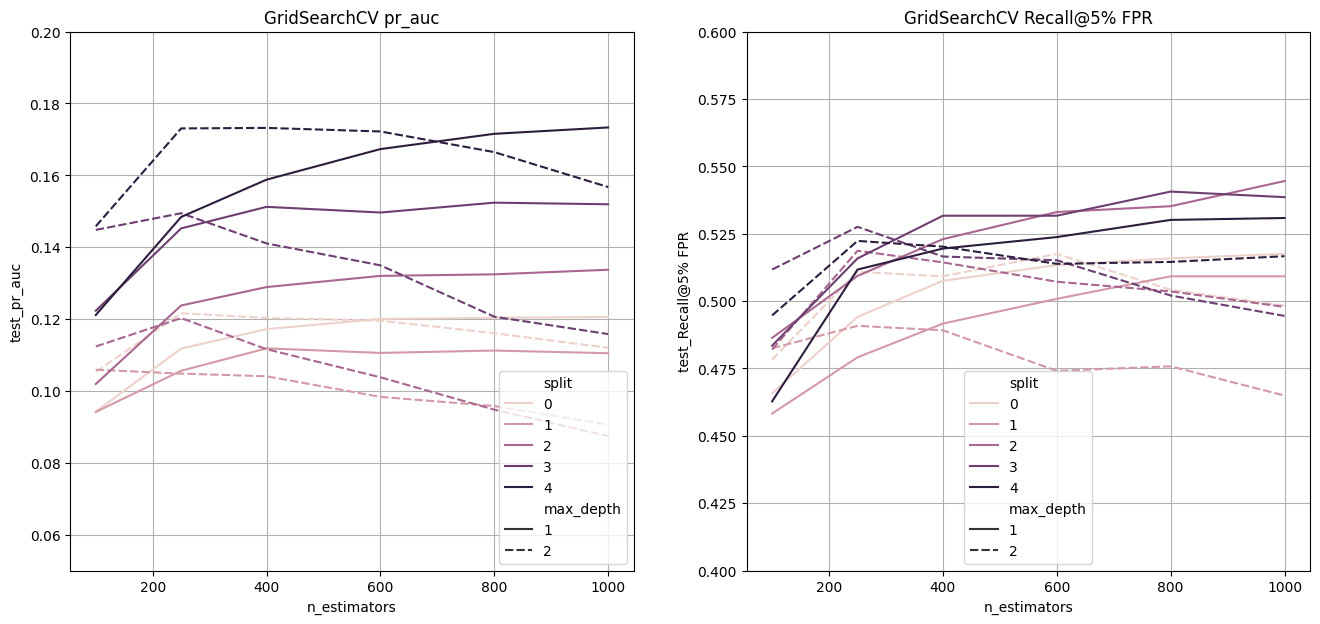

In [43]:
_res = imb_gs_xgb_1.cv_results_
_cv = cv_imb

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_n_estimators'][i], _res['param_max_depth'][i], _res[f'split{j}_test_pr_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['n_estimators', 'max_depth', 'test_pr_auc', 'test_Recall@5% FPR', 'split'])

imb_xgb_res, imb_xgb_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

sns.lineplot(data=_df, x='n_estimators', y='test_pr_auc', ax=imb_xgb_axes[0], hue='split', style='max_depth')
sns.lineplot(data=_df, x='n_estimators', y='test_Recall@5% FPR', ax=imb_xgb_axes[1], hue='split', style='max_depth')

imb_xgb_axes[0].set_ylim((0.05, 0.2))
imb_xgb_axes[1].set_ylim((0.4, 0.6))

imb_xgb_axes[0].grid(True)
imb_xgb_axes[1].grid(True)

imb_xgb_axes[0].set_title('GridSearchCV pr_auc')
imb_xgb_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

I'll try to change the regularization strength

In [44]:
%%time

imb_xgb_params_gs_2 = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'learning_rate': 0.1,
    'subsample': 0.6,
    'colsample_bytree': 0.4, 
    'min_child_weight': 0.1, 
    'gamma': 0.4,
    'eval_metric': 'logloss',
    'seed': 42,
    'max_depth': 1,
    'n_estimators': 1000
}

imb_xgb_2 = XGBClassifier(**imb_xgb_params_gs_2)


reg_alpha = [0.4, 1, 3]
reg_lambda = [0.4, 1, 3]


imb_gs_xgb_2 = GridSearchCV(
    imb_xgb_2, 
    param_grid={'reg_alpha': reg_alpha, 'reg_lambda': reg_lambda},
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    refit='Recall@5% FPR', 
    n_jobs=-1, 
    cv=cv_imb,
    return_train_score=True
)

imb_gs_xgb_2.fit(X_imb, y_imb)

CPU times: total: 8min 23s
Wall time: 4min 5s


GridSearchCV(cv=[(RangeIndex(start=0, stop=133928, step=1),
                  RangeIndex(start=133928, stop=261548, step=1)),
                 (RangeIndex(start=261548, stop=502440, step=1),
                  RangeIndex(start=502440, stop=639419, step=1)),
                 (RangeIndex(start=639419, stop=987275, step=1),
                  RangeIndex(start=987275, stop=1138211, step=1)),
                 (RangeIndex(start=1138211, stop=1610353, step=1),
                  RangeIndex(start=161...
                                     multi_strategy=None, n_estimators=1000,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'reg_alpha': [0.4, 1, 3], 'reg_lambda': [0.4, 1, 3]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'})

The parameters did not affect the score in any way

In [45]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(imb_gs_xgb_2.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75
_res_df['test_pr_auc_metric'] = _res_df['mean_test_pr_auc'] - _res_df['std_test_pr_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric',
     'mean_train_pr_auc', 'mean_test_pr_auc', 'std_test_pr_auc', 'test_pr_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,test_pr_auc_metric
3,"{'reg_alpha': 1, 'reg_lambda': 0.4}",0.826272,0.529001,0.013224,0.519084,0.959829,0.886773,0.010868,0.878622,0.751946,0.138179,0.022683,0.121166
1,"{'reg_alpha': 0.4, 'reg_lambda': 1}",0.826237,0.528576,0.013100,0.518751,0.959826,0.886774,0.010868,0.878623,0.751727,0.138147,0.022635,0.121171
8,"{'reg_alpha': 3, 'reg_lambda': 3}",0.826297,0.527578,0.012141,0.518473,0.959855,0.886720,0.010793,0.878625,0.752180,0.137887,0.022504,0.121009
0,"{'reg_alpha': 0.4, 'reg_lambda': 0.4}",0.826152,0.528271,0.013124,0.518429,0.959824,0.886757,0.010855,0.878616,0.751647,0.137937,0.022508,0.121055
7,"{'reg_alpha': 3, 'reg_lambda': 1}",0.826200,0.528341,0.013909,0.517909,0.959827,0.886913,0.010867,0.878763,0.751971,0.138594,0.022181,0.121958
6,"{'reg_alpha': 3, 'reg_lambda': 0.4}",0.826125,0.528174,0.014171,0.517546,0.959826,0.886835,0.010951,0.878622,0.752126,0.138438,0.022389,0.121646
4,"{'reg_alpha': 1, 'reg_lambda': 1}",0.826287,0.527728,0.013906,0.517299,0.959840,0.886857,0.010853,0.878717,0.751958,0.138264,0.022429,0.121442
2,"{'reg_alpha': 0.4, 'reg_lambda': 3}",0.826253,0.528388,0.015148,0.517026,0.959838,0.886744,0.010946,0.878534,0.752077,0.138130,0.022599,0.121181
5,"{'reg_alpha': 1, 'reg_lambda': 3}",0.825948,0.526973,0.015863,0.515075,0.959851,0.886826,0.010952,0.878612,0.752128,0.137905,0.022781,0.120820


Train the model with the best parameters

In [46]:
%%time

final_pos_rate=0.04
synt_rate=0.72

smote_strat = final_pos_rate / (1 - final_pos_rate)
nm_strat = (1 - synt_rate) * smote_strat

nm = NearMiss(
    sampling_strategy=nm_strat, 
    n_jobs=-1,
)
smote = SMOTE(
    sampling_strategy=smote_strat, 
    random_state=42,
)
    
pipe_imb = ImbPipeline([
    ('nm', nm),
    ('smote', smote),
])

preprocessor.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

resampled_X, resampled_y = pipe_imb.fit_resample(preprocessor.transform(X_train[X_train.month<=4]), y_train[X_train.month<=4])

xgb_params = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'n_estimators': 1000,
    'max_depth': 1,
    'learning_rate': 0.1,
    'subsample': 0.6,
    'colsample_bytree': 0.4, 
    'min_child_weight': 0.1, 
    'gamma': 0.4,
    'reg_alpha': 1,
    'reg_lambda': 0.4,
    'eval_metric': 'logloss',
    'seed': 42,    
}

xgb = XGBClassifier(**xgb_params)


pipe_xgb = Pipeline([
    ('model', xgb),
])

pipe_xgb.fit(resampled_X, resampled_y)

CPU times: total: 3min
Wall time: 27.8 s


Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster='gbtree',
                               callbacks=None, colsample_bylevel=None,
                               colsample_bynode=None, colsample_bytree=0.4,
                               device=None, early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=0.4, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=1, max_leaves=None,
                               min_child_weight=0.1, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=None,
                               num_parallel_tree=None, ...))])

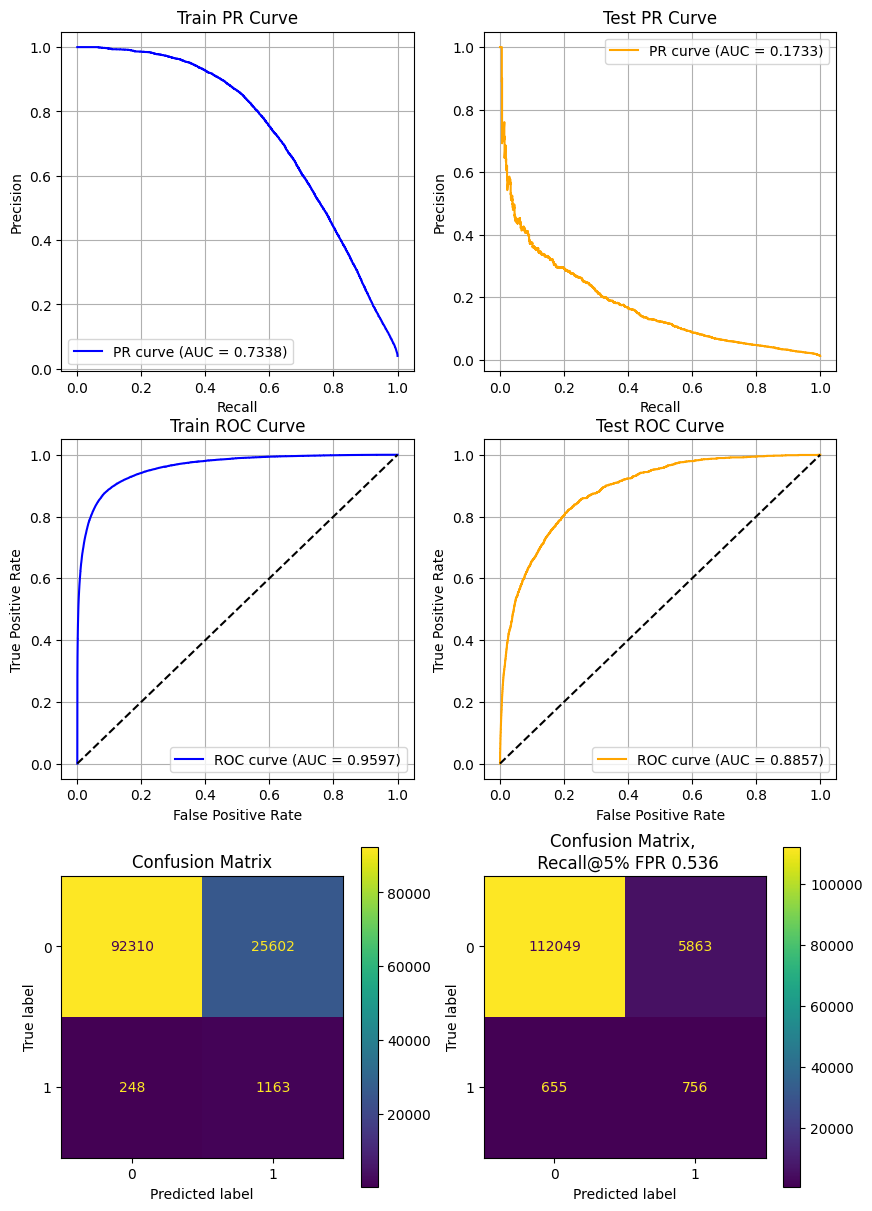

In [47]:
fig_xgb, axes_xgb = model_report(
    pipe_xgb, 
    resampled_X, resampled_y, 
    preprocessor.transform(X_train[X_train.month==5]), y_train[X_train.month==5],
)
plt.show()

The resulting model shows similar performance to the previous XGBoost model. The large differences in performance between the training and test sets are explained by resampling

Training the model on resampled data did not significantly improve the scores

# Optuna

Optuna is an hyperparameter optimization framework that automatically find the best parameters. It searches the parameter space, trying different combinations, and learning from past trials to pick the next ones more intelligently.

In [48]:
#path to db
storage = f"sqlite:///{(PROJECT_ROOT / 'training' / 'optuna' / 'optuna_study.db').as_posix()}"

## Optuna RandomForest

In [49]:
def objective_forest(trial):
    """
    Define the mesh parameters and scoring function
    """

    min_samples_split = trial.suggest_float("min_samples_split", 1e-5, 1e-3, log=True)
    min_samples_leaf = trial.suggest_float("min_samples_leaf", 1e-7, min_samples_split * 0.1, log=True)
    
    params = {
        "class_weight": "balanced_subsample", 
        "random_state": 42,
        "n_jobs": -1,
        "bootstrap": True,
        "criterion": "log_loss",
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-5, 1e-2, log=True),
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf,
        "max_depth": trial.suggest_int("max_depth", 16, 40, step=2),
        "n_estimators": trial.suggest_int("n_estimators", 80, 350, step=10),
    }
       
    score = cross_val_score(
        RandomForestClassifier(**params), X_cv_small, y_cv_small, 
        scoring=recall_a5_fpr,
        cv=cv_small, 
        n_jobs=-1,
        error_score='raise'
    )
    
    return score.mean() - score.std() * 0.75

In [50]:
%%time 
study_forest = optuna.create_study(
    direction="maximize",
    study_name="forest_small_v0",  
    storage=storage,  
    load_if_exists=True,  
)

study_forest.optimize(objective_forest, n_trials=20)

[I 2025-10-21 15:42:41,617] A new study created in RDB with name: forest_small_v0
[I 2025-10-21 15:43:56,643] Trial 0 finished with value: 0.48324519966599694 and parameters: {'min_samples_split': 3.803787620696085e-05, 'min_samples_leaf': 1.5059571780481898e-06, 'min_impurity_decrease': 4.457702767571811e-05, 'max_depth': 34, 'n_estimators': 270}. Best is trial 0 with value: 0.48324519966599694.
[I 2025-10-21 15:44:53,520] Trial 1 finished with value: 0.4736480900391691 and parameters: {'min_samples_split': 1.3361502414395289e-05, 'min_samples_leaf': 8.55425619273334e-07, 'min_impurity_decrease': 0.0007886881777598767, 'max_depth': 16, 'n_estimators': 260}. Best is trial 0 with value: 0.48324519966599694.
[I 2025-10-21 15:45:12,536] Trial 2 finished with value: 0.46154388521591855 and parameters: {'min_samples_split': 1.3608102968092294e-05, 'min_samples_leaf': 1.6790707938961469e-07, 'min_impurity_decrease': 0.001043161999860099, 'max_depth': 22, 'n_estimators': 90}. Best is trial 0 

CPU times: total: 8.23 s
Wall time: 21min 28s


Scores are quite low

In [51]:
study_forest.trials_dataframe().drop(
    ['number', 'datetime_start', 'datetime_complete', 'duration', 'state'], 
    axis=1
).sort_values(by='value', ascending=False).head(6)

,value,params_max_depth,params_min_impurity_decrease,params_min_samples_leaf,params_min_samples_split,params_n_estimators
11,0.494121,40,0.000136,4.968580e-06,0.000230,350
10,0.493609,40,0.000172,3.336665e-06,0.000215,350
12,0.493337,34,0.000164,4.940580e-06,0.000080,350
8,0.490213,40,0.000054,3.787480e-07,0.000232,300
16,0.489452,36,0.000129,2.834812e-06,0.000162,320
3,0.487867,26,0.000017,1.151829e-07,0.000176,280


I'll take the average parameters that produced the best results (optuna results may have changed when restarting)

In [52]:
%%time

forest_cv_opt_0 = cross_validate(
    RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
        min_impurity_decrease=2.2e-4, n_estimators=300, max_depth=30, min_samples_leaf=9e-6, min_samples_split=9e-4,
    ),   
    X_cv_nf, y_cv_nf, 
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    cv=cv_nf, 
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
)

print('Recall_metric:', forest_cv_opt_0['test_Recall@5% FPR'].mean() - forest_cv_opt_0['test_Recall@5% FPR'].std() * 0.75)
print('PR_auc_metric:', forest_cv_opt_0['test_pr_auc'].mean() - forest_cv_opt_0['test_pr_auc'].std() * 0.75)
print('roc_auc_metric:',forest_cv_opt_0['test_roc_auc'].mean() - forest_cv_opt_0['test_roc_auc'].std() * 0.75)
print()

pd.DataFrame(forest_cv_opt_0)

Recall_metric: 0.49698253078841004
PR_auc_metric: 0.11485626888385167
roc_auc_metric: 0.8707539648231252

CPU times: total: 1.09 s
Wall time: 3min 1s


,fit_time,score_time,estimator,test_Recall@5% FPR,train_Recall@5% FPR,test_pr_auc,train_pr_auc,test_roc_auc,train_roc_auc
0,45.413621,2.184933,"(DecisionTreeClassifier(criterion='log_loss', ...",0.485810,0.998667,0.104986,0.524297,0.861367,0.991094
1,94.473892,1.862345,"(DecisionTreeClassifier(criterion='log_loss', ...",0.505843,0.803188,0.109205,0.289102,0.871527,0.972995
2,136.995020,1.363684,"(DecisionTreeClassifier(criterion='log_loss', ...",0.522989,0.674281,0.136459,0.205050,0.898874,0.954564
3,166.930964,0.638233,"(DecisionTreeClassifier(criterion='log_loss', ...",0.509642,0.600416,0.146858,0.164232,0.895955,0.937082
4,179.230836,0.285655,"(DecisionTreeClassifier(criterion='log_loss', ...",0.505315,0.569881,0.141635,0.150245,0.879589,0.924580


In [53]:
%%time

forest_cv_opt_1 = cross_validate(
    RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
        min_impurity_decrease=7e-5, n_estimators=200, max_depth=38, min_samples_leaf=3e-6, min_samples_split=1e-4,
    ),   
    X_cv_nf, y_cv_nf, 
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    cv=cv_nf, 
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
)

print('Recall_metric:', forest_cv_opt_1['test_Recall@5% FPR'].mean() - forest_cv_opt_1['test_Recall@5% FPR'].std() * 0.75)
print('PR_auc_metric:', forest_cv_opt_1['test_pr_auc'].mean() - forest_cv_opt_1['test_pr_auc'].std() * 0.75)
print('roc_auc_metric:',forest_cv_opt_1['test_roc_auc'].mean() - forest_cv_opt_1['test_roc_auc'].std() * 0.75)
print()

pd.DataFrame(forest_cv_opt_1)

Recall_metric: 0.49754237683249924
PR_auc_metric: 0.1114815764324162
roc_auc_metric: 0.8680839256656413

CPU times: total: 1.19 s
Wall time: 2min 12s


,fit_time,score_time,estimator,test_Recall@5% FPR,train_Recall@5% FPR,test_pr_auc,train_pr_auc,test_roc_auc,train_roc_auc
0,31.613292,1.777295,"(DecisionTreeClassifier(criterion='log_loss', ...",0.479132,1.000000,0.102292,0.983366,0.855340,0.999883
1,66.620224,1.486621,"(DecisionTreeClassifier(criterion='log_loss', ...",0.509182,1.000000,0.105031,0.827234,0.868622,0.998585
2,96.945358,1.171619,"(DecisionTreeClassifier(criterion='log_loss', ...",0.522989,1.000000,0.130260,0.584663,0.898337,0.995135
3,120.222782,0.545068,"(DecisionTreeClassifier(criterion='log_loss', ...",0.522039,1.000000,0.142641,0.417526,0.896544,0.989763
4,130.050597,0.245978,"(DecisionTreeClassifier(criterion='log_loss', ...",0.514529,0.974036,0.147514,0.321655,0.883376,0.983364


Pick the best parameters

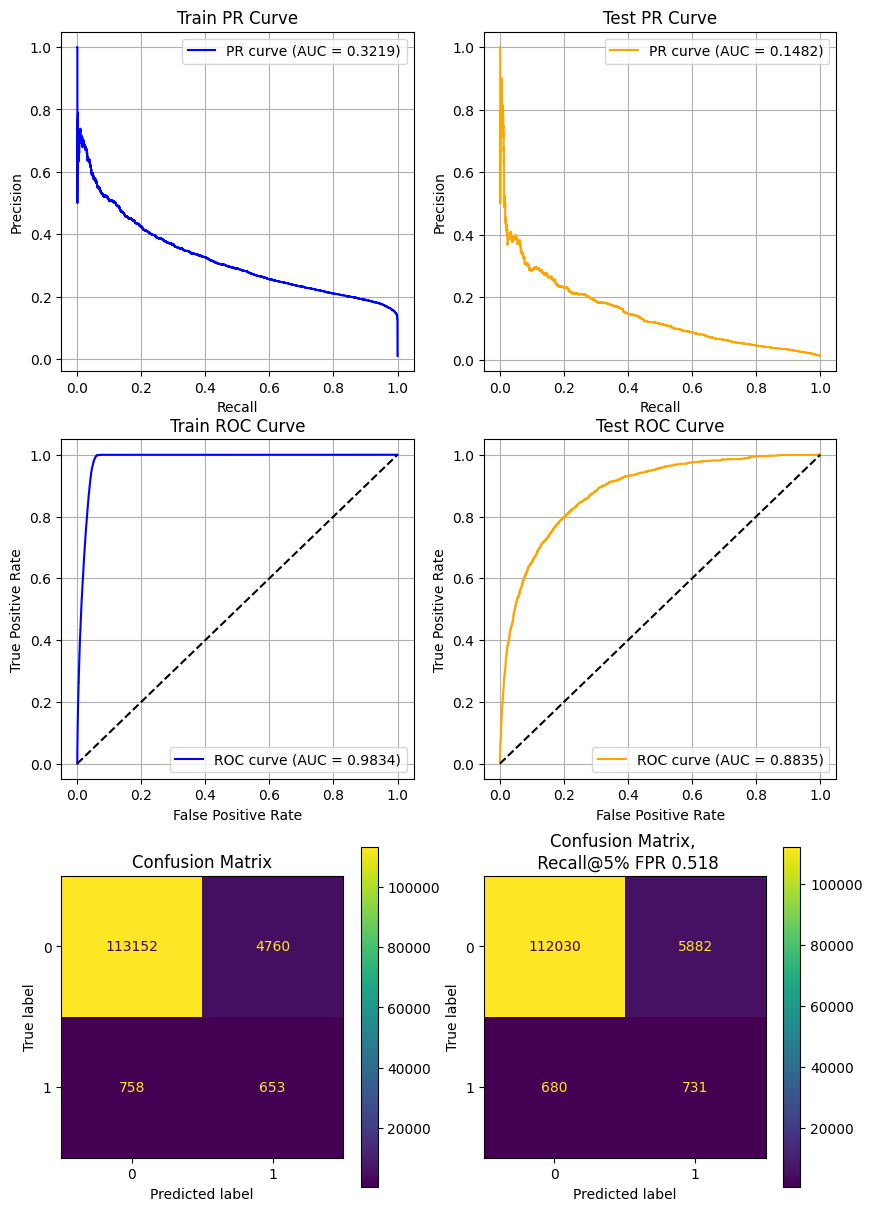

CPU times: total: 10min 24s
Wall time: 1min 15s


In [54]:
%%time

final_forest_params = {
    "class_weight": "balanced_subsample", 
    "random_state": 42,
    "n_jobs": -1,
    "bootstrap": True,
    "criterion": "log_loss",
    "min_samples_leaf": 3e-6,
    "min_impurity_decrease": 7e-5,
    "min_samples_split": 1e-4,
    "max_depth": 38,
    "n_estimators": 250,
}

final_forest = RandomForestClassifier(**final_forest_params)


final_pipe_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_forest),
])

final_pipe_forest.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])


final_forest_fig, final_xgb_axes = model_report(
    final_pipe_forest, 
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

## Optuna XGBoost

In [55]:
def objective_xgb(trial):
    """
    Define the mesh parameters and scoring function
    """
    params = {
        "booster":'gbtree',
        "scale_pos_weight": (len(y_train) - np.sum(y_train)) / np.sum(y_train),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, step=0.01),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1400, step=10),
        "max_depth": trial.suggest_int("max_depth", 1, 9),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0, step=0.05),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0, step=0.05),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.01, 0.3, step=0.01),       
        "gamma": trial.suggest_float("gamma", 0, 0.4, step=0.01),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100, log=True),
        "eval_metric": "logloss"
    }
    
    score = cross_val_score(
        XGBClassifier(**params), X_cv_nf, y_cv_nf, 
        scoring=recall_a5_fpr,
        cv=cv_nf, 
        n_jobs=-1,
        error_score='raise'
    )
    
    return score.mean() - score.std() * 0.75

In [56]:
%%time 
study_xgb = optuna.create_study(
    direction="maximize",
    study_name="xgb_v0",  
    storage=storage,  
    load_if_exists=True,  
)

study_xgb.optimize(objective_xgb, n_trials=35)

[I 2025-10-21 16:10:40,094] A new study created in RDB with name: xgb_v0
[I 2025-10-21 16:12:14,605] Trial 0 finished with value: 0.48716716492239015 and parameters: {'learning_rate': 0.03, 'n_estimators': 1320, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.5, 'min_child_weight': 0.11, 'gamma': 0.26, 'reg_alpha': 0.8230739824878275, 'reg_lambda': 8.62217942702234e-06}. Best is trial 0 with value: 0.48716716492239015.
[I 2025-10-21 16:13:16,298] Trial 1 finished with value: 0.42777056999131685 and parameters: {'learning_rate': 0.08, 'n_estimators': 1220, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 0.4, 'min_child_weight': 0.05, 'gamma': 0.12, 'reg_alpha': 0.01143348501684813, 'reg_lambda': 8.152836301786818}. Best is trial 0 with value: 0.48716716492239015.
[I 2025-10-21 16:13:41,199] Trial 2 finished with value: 0.49944776241422006 and parameters: {'learning_rate': 0.06999999999999999, 'n_estimators': 310, 'max_depth': 5, 'subsample': 0.6000000000000001, 'colsample_

CPU times: total: 18.7 s
Wall time: 22min 8s


Scores are better, than scores of the RandomForest

In [57]:
study_xgb.trials_dataframe().drop(
    ['number', 'datetime_start', 'datetime_complete', 'duration', 'state'], 
    axis=1
).sort_values(by='value', ascending=False).head(6)

,value,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample
22,0.539618,0.95,0.36,0.18,1,0.04,350,5.324588e-02,0.000162,0.45
10,0.539008,0.95,0.40,0.19,1,0.02,230,9.274896e+01,0.000006,0.40
15,0.538803,0.90,0.35,0.16,1,0.01,580,1.095728e-08,0.000161,0.65
24,0.537304,0.95,0.36,0.13,1,0.04,360,7.007898e-05,0.000049,0.45
21,0.536488,1.00,0.37,0.19,1,0.01,330,5.108362e-02,0.000102,0.40
12,0.536378,1.00,0.40,0.20,1,0.01,200,2.547239e+01,0.000014,0.40


I'll take the average parameters that produced the best results (optuna results may have changed when restarting)

In [58]:
%%time

xgb_params_opt = {
    "booster":'gbtree',
    "scale_pos_weight": (len(y_train) - np.sum(y_train)) / np.sum(y_train),
    "n_estimators": 650,
    "max_depth": 2,
    "learning_rate": 0.12,
    "subsample": 0.85,
    "colsample_bytree": 0.8,
    "min_child_weight": 0.26,     
    "gamma": 0.13,
    "reg_alpha": 1.5e-4,
    "reg_lambda": 80,
    "eval_metric": "logloss"
}

xgb_opt = XGBClassifier(**xgb_params_opt)

xgb_cv_opt = cross_validate(
    xgb_opt,
    X_cv_nf, y_cv_nf, 
    scoring={'Recall@5% FPR': recall_a5_fpr,
             'pr_auc': 'average_precision',
             'roc_auc': 'roc_auc'},
    cv=cv_nf, 
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
)

print('Recall_metric:', xgb_cv_opt['test_Recall@5% FPR'].mean() - xgb_cv_opt['test_Recall@5% FPR'].std() * 0.75)
print('PR_auc_metric:', xgb_cv_opt['test_pr_auc'].mean() - xgb_cv_opt['test_pr_auc'].std() * 0.75)
print('roc_auc_metric:', xgb_cv_opt['test_roc_auc'].mean() - xgb_cv_opt['test_roc_auc'].std() * 0.75)
print()

pd.DataFrame(xgb_cv_opt)

Recall_metric: 0.5352380267209983
PR_auc_metric: 0.13625501376526283
roc_auc_metric: 0.8848646973074397

CPU times: total: 4.67 s
Wall time: 35.5 s


,fit_time,score_time,estimator,test_Recall@5% FPR,train_Recall@5% FPR,test_pr_auc,train_pr_auc,test_roc_auc,train_roc_auc
0,7.752953,0.465455,"XGBClassifier(base_score=None, booster='gbtree...",0.524207,0.572000,0.121779,0.183532,0.875344,0.928103
1,13.374804,0.380584,"XGBClassifier(base_score=None, booster='gbtree...",0.537563,0.576723,0.129426,0.165302,0.884755,0.914675
2,20.310463,0.376152,"XGBClassifier(base_score=None, booster='gbtree...",0.581178,0.563655,0.159864,0.157918,0.911231,0.909559
3,27.793108,0.376090,"XGBClassifier(base_score=None, booster='gbtree...",0.582645,0.574130,0.183476,0.159720,0.909323,0.910920
4,33.185134,0.264846,"XGBClassifier(base_score=None, booster='gbtree...",0.540751,0.576409,0.191052,0.166323,0.895631,0.911305


The model is fitted well: train and test scores are close and high, scores are similar with scores I have recieved at GridSearch and cross-validation. But this model has fewer estimators, works a little faster, so I'll chose theese parameters to the final model

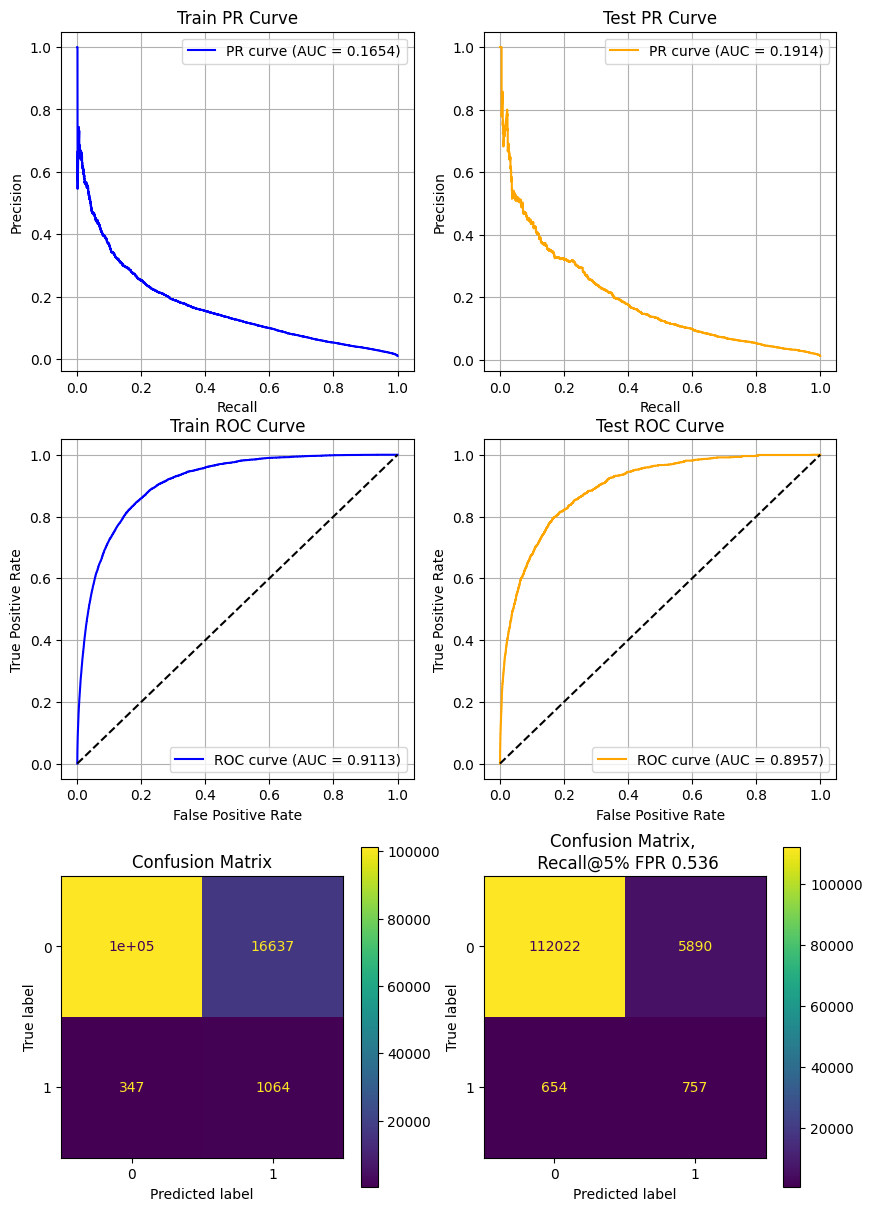

CPU times: total: 1min 18s
Wall time: 25.4 s


In [59]:
%%time

final_xgb_params = {
    "booster":'gbtree',
    "scale_pos_weight": (len(y_train) - np.sum(y_train)) / np.sum(y_train),
    "n_estimators": 650,
    "max_depth": 2,
    "learning_rate": 0.12,
    "subsample": 0.85,
    "colsample_bytree": 0.8,
    "min_child_weight": 0.26,     
    "gamma": 0.13,
    "reg_alpha": 1.5e-4,
    "reg_lambda": 80,
    "eval_metric": "logloss",
    "seed": 42
}

final_xgb = XGBClassifier(**final_xgb_params)

final_pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_xgb),
])

final_pipe_xgb.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])


final_xgb_fig, final_xgb_axes = model_report(
    final_pipe_xgb, 
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

## Conclusion

Hyperparameters were selected for both the RandomForest and XGBoost models. The Recall@5% FPR for both models exceeds 0.5

The RandomForest model shows worse performance than XGBoost. Its performance on the training set is noticeably better than on the test set, which may indicate signs of overfitting. However, the best scores were obtained with these overfitted models

The XGBoost model achieves better results. In addition, its performance on the training and test sets is fairly close, indicating the absence of overfitting

# Statistical test for model selection

The scores of the XGBoost model are better than the scores of the RandomForest model. However, it is incorrect to compare only the two scores - perhaps in fact the models predict approximately the same. To test this, a statistical test will be performed to determine whether the mean predictions of the two models are equal.

## Final models

In [60]:
%%time
# training on the whole training sample

final_pipe_xgb.fit(X_train, y_train)
final_pipe_forest.fit(X_train, y_train)
print('fitted')

fitted
CPU times: total: 13min 19s
Wall time: 1min 35s


In [61]:
# preprocess test data (models have the same preprocessing)
X_test_transformed = final_pipe_xgb['preprocessor'].transform(X_test)
X_test_transformed.index = y_test.index

## Determining the size of bootstrap samples and the number of experiments

To select a model, a paired statistical test for equality of the mean samples of the Recall@5% FPR metric values will be conducted.

The target metric is measured on a sample, not on a single object. The test sample consists of 200 thousand independent applications. Conducting measurements on a large number of bootstrap subsamples of 200 thousand requires a lot of time. To optimize the time resources spent on conducting the test, bootstrap subsamples of a smaller size will be used.

Input data for the test:

- $H_0$: The average difference in metrics between the two models is zero, meaning the models do not differ in metrics;
- $H_1$: The average difference in metrics between the two models is not zero, the models are different;
- minimum detectable effect Δ = 0.005;
- significance level &alpha; = 0.05;
- power &beta; = 0.8.

It is possible to carry out 1000 tests, but I should to determine the size of a bootsrap sample *m*. To determine this, I will conduct a pilot test: on N_0 = 400 iterations for samples of size *m* = (1000, 2000, 5000, 8000, 12000), I will determine the standard deviation of the differences in metrics between models on these m. I will determine the sample size at which the reduction in variance is satisfactory.

In [62]:
delta = 0.005 # MDE
alpha = 0.05
beta = 0.8 # power

N = 1000 # number of tests (final sample size)

N_0 = 400 
ms = [1000, 2000, 5000, 8000, 12000] # bootstrapped sample sizes

In [63]:
samples = dict() # dictionary with 400 arrays of indexes for every size of bootstrapped sample

for m in ms:
    idx = []
    for  _ in range(N_0):
        idx.append(np.random.choice(X_test_transformed.index, size=m, replace=True))
    samples[m] = idx

In [64]:
%%time

scorer_forest = check_scoring(final_pipe_forest['model'], scoring=recall_a5_fpr)
scorer_xgb = check_scoring(final_pipe_xgb['model'], scoring=recall_a5_fpr)

scores_m = dict() # dictionary with 400 tuples of scores for every size of bootstrapped sample

for m in ms:
    scores_xgb = []
    scores_forest = []
    for idx in samples[m]:
        scores_xgb.append(scorer_xgb(final_pipe_xgb['model'],  X_test_transformed.loc[idx], y_test.loc[idx]))
        scores_forest.append(scorer_forest(final_pipe_forest['model'],  X_test_transformed.loc[idx], y_test.loc[idx]))
    
    scores_m[m] = (np.array(scores_xgb), np.array(scores_forest))

CPU times: total: 24min 16s
Wall time: 2min 12s


In [65]:
results = dict() # dictionary with standard deviations for every size of bootstrapped sample

for m in ms:
    d_0 = scores_m[m][0] - scores_m[m][1] # array with difference of scores
    
    results[m] = np.std(d_0, ddof=1)

The standard deviation decreases as the size of the bootstrapped samples increases

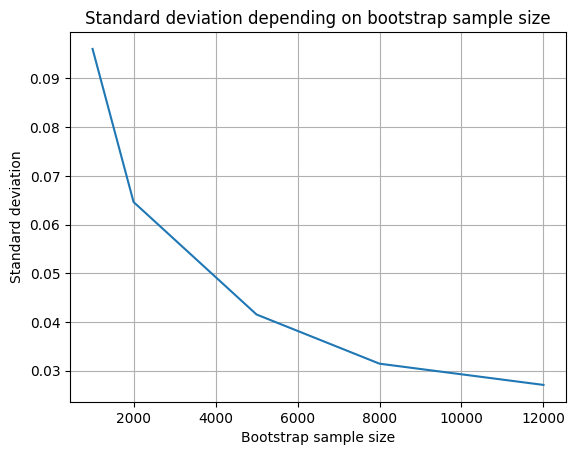

In [66]:
st_figure = plt.figure()
sns.lineplot(x=list(results.keys()), y=list(results.values()))
plt.title("Standard deviation depending on bootstrap sample size")
plt.xlabel("Bootstrap sample size")
plt.ylabel("Standard deviation")
plt.grid(True)
plt.show()

Because 
$$ s * \sqrt{m} \approx constant$$
I can use the ratio to predict the variance, depending on *m* - $\sigma^2(m)$

Formula of Minimum Detectable Effect (MDE):
$$
effect = (t_{(1-\frac{\alpha}{2})}+ t_\beta)s\sqrt{\frac{1}{N}}
$$
so 
$$s(m) = \frac{\sqrt{N} * effect }{ (t_{(1-\frac{\alpha}{2})}+ t_\beta)}
$$
and 
$$
m \approx \frac {m_i * s(m_i)^2}{s(m)^2}  = \frac {m_i * s(m_i)^2}{\left(\frac{\sqrt{N} * effect }{(t_{(1-\frac{\alpha}{2})}+ t_\beta)}\right)^2} = m_i * s(m_i)^2 * \frac {(t_{(1-\frac{\alpha}{2})}+ t_\beta)^2}{N* (effect) ^2 }
$$

In [67]:
max_constant = 0
for m in ms:
    val = results[m]  * np.sqrt(m)
    print(f"C({m}) = {val:.2f}")
    if val > max_constant:
        max_constant = val
del val

C(1000) = 3.04
C(2000) = 2.89
C(5000) = 2.94
C(8000) = 2.81
C(12000) = 2.97


In [68]:
final_m = max_constant**2 * (t(N-1).ppf(q=1-alpha/2) + t(N-1).ppf(q=beta))**2 / delta**2 / N
print(f"Calculated m: {int(final_m)}")

inc_coef = 1.3  # increase the size

final_m = int(np.ceil(final_m * inc_coef / 100) * 100)
print(f"Accepted m: {int(final_m)}")

Calculated m: 2902
Accepted m: 3800


## t-test

Creating *N* bootstrapped samples of size *m* and getting the scores of the models

In [69]:
%%time

scorer_forest = check_scoring(final_pipe_forest['model'], scoring=recall_a5_fpr)
scorer_xgb = check_scoring(final_pipe_xgb['model'], scoring=recall_a5_fpr)

final_scores_xgb = []
final_scores_forest = []


for _ in range(N):
    idx = np.random.choice(X_test_transformed.index, size=final_m, replace=True)

    final_scores_xgb.append(scorer_xgb(final_pipe_xgb['model'],  X_test_transformed.loc[idx], y_test.loc[idx]))
    final_scores_forest.append(scorer_forest(final_pipe_forest['model'],  X_test_transformed.loc[idx], y_test.loc[idx]))
    
final_scores_xgb = np.array(final_scores_xgb)
final_scores_forest = np.array(final_scores_forest)

CPU times: total: 11min 11s
Wall time: 60 s


It is evident that the distribution of the XGBoost scores is shifted to the right

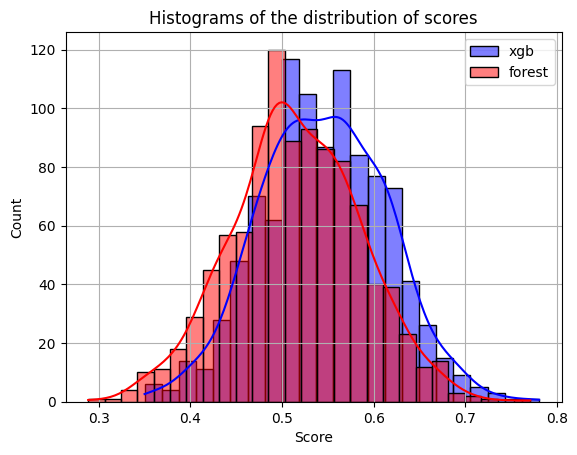

In [70]:
distibutions_plot = plt.figure()
sns.histplot(final_scores_xgb, color='blue', label='xgb', kde=True, alpha=0.5)
sns.histplot(final_scores_forest, color='red', label='forest', kde=True, alpha=0.5)
plt.title('Histograms of the distribution of scores')
plt.legend()
plt.xlabel("Score")
plt.grid(True)
plt.show()

In [71]:
ttest_rel(final_scores_xgb, final_scores_forest, alternative='two-sided')

TtestResult(statistic=19.783703423458217, pvalue=9.154903990773016e-74, df=999)

The p-value is below the accepted significance level, so the null hypothesis - that the average difference in metrics between the two models is zero, meaning the models do not differ in performance - can be rejected. The distribution of XGBoost scores is skewed to the right, indicating that its results are better

# Probability calibration

Most likely, the probabilities predicted by the model will not coincide with the real distribution of classes. To check this, I will build a calibration curve

The predicted probabilities are indeed far from the real distribution. It is necessary to calibrate the probabilities - to adjust the predictions to the real distribution of classes (to bring the probability curve closer to the diagonal)

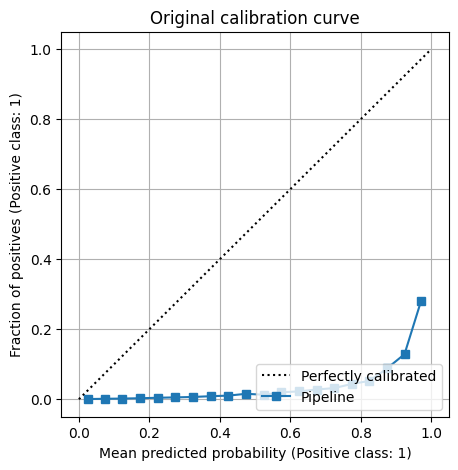

In [72]:
CalibrationDisplay.from_estimator(final_pipe_xgb, X_test, y_test, n_bins=20).figure_.set_size_inches(5, 5)
plt.title('Original calibration curve')
plt.grid()
plt.show()

I will use Platt's calibration, which is based on the sigmoid function. The model will return calibrated probability estimates.

In [73]:
%%time

platts_calibration = CalibratedClassifierCV(
    final_pipe_xgb,
    method='sigmoid',
    ensemble=False,
    cv=5,
    n_jobs = -1
).fit(X_train, y_train)

CPU times: total: 1min 16s
Wall time: 1min 10s


The maximum predicted probability now does not exceed 0.2 (previously it was almost 1) - this is logical, given the distribution of the target class (only 1%), so even if the model sees a fraudulent application, it cannot be 99% sure due to their rarity

Starting with a probability of ~0.12, the distribution of predicted probabilities begins to diverge from the distribution of the target class. However, if you look at the distribution of predicted probabilities, you can see that this is due to the fact that there are very few such objects

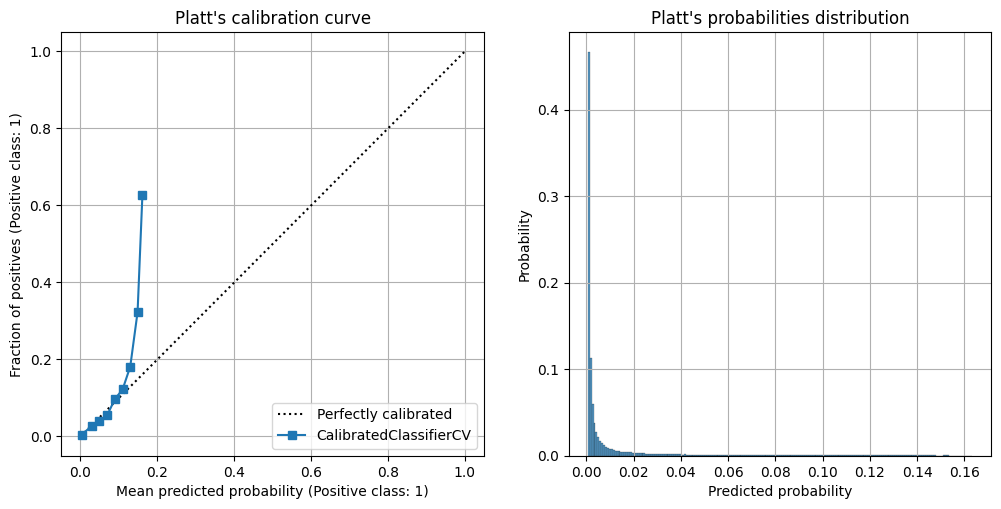

CPU times: total: 7.88 s
Wall time: 5.35 s


In [74]:
%%time

fig_platt, axes_platt = plt.subplots(1, 2, figsize=(12, 5.5))

CalibrationDisplay.from_estimator(platts_calibration, X_test, y_test, n_bins=50, ax=axes_platt[0])
axes_platt[0].grid()
axes_platt[0].set_title("Platt's calibration curve")

platts_p = platts_calibration.predict_proba(X_test)[:, 1]

sns.histplot(platts_p, bins=200, ax=axes_platt[1], stat='probability')
axes_platt[1].set_xlabel('Predicted probability')
axes_platt[1].grid()
axes_platt[1].set_title("Platt's probabilities distribution")

plt.show()

I will also try using the isotonic method. This method is not based on the sigmoid function, but on an arbitrary monotonic function. On large datasets, it can produce better results than Platt's calibration.

In [75]:
%%time

iso_calibration = CalibratedClassifierCV(
    final_pipe_xgb,
    method='isotonic',
    ensemble=False,
    cv=5,
    n_jobs = -1
).fit(X_train, y_train)

CPU times: total: 1min 17s
Wall time: 1min 10s


The maximum predicted probability is now close to 1 again, but for probabilities greater than 0.2 the curve is unstable.

The distribution of predicted probabilities is similar to the previous one, but not smoothed.

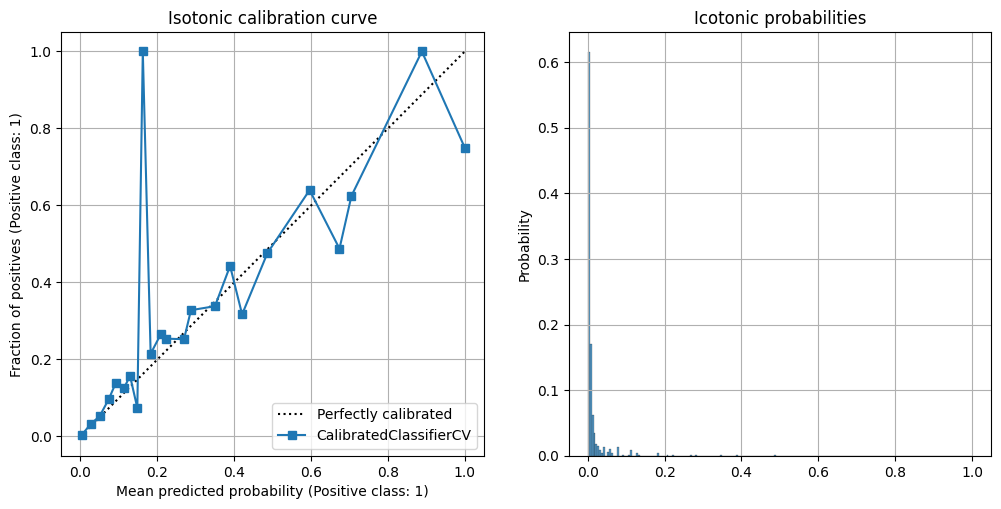

CPU times: total: 7.58 s
Wall time: 4.92 s


In [76]:
%%time

fig_iso, axes_iso = plt.subplots(1, 2, figsize=(12, 5.5))

CalibrationDisplay.from_estimator(iso_calibration, X_test, y_test, n_bins=50, ax=axes_iso[0])
axes_iso[0].grid()
axes_iso[0].set_title("Isotonic calibration curve")

iso_p = iso_calibration.predict_proba(X_test)[:, 1]

sns.histplot(iso_p, bins=200, ax=axes_iso[1], stat='probability')
axes_platt[1].set_xlabel('Predicted probability')
axes_iso[1].grid()
axes_iso[1].set_title("Icotonic probabilities")

plt.show()

I will compare the metric values for the two methods

In [77]:
%%time
def expected_calibration_error(y_true, y_prob, n_bins=20):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (y_prob > bins[i]) & (y_prob <= bins[i+1])
        if np.sum(mask) == 0:
            continue
        bin_prob = np.mean(y_prob[mask])
        bin_true = np.mean(y_true[mask])
        ece += (np.sum(mask) / len(y_true)) * abs(bin_prob - bin_true)
    return ece


p = platts_p
scorer_xgb_platt = check_scoring(platts_calibration , scoring=recall_a5_fpr)
print("sigmoid")
print("=======")
print("Brier:", np.round(brier_score_loss(y_test, p), 4))
print("LogLoss:", np.round(log_loss(y_test, p), 4))
print("ECE(50):", np.round(expected_calibration_error(y_test, p, n_bins=50), 4))
print("AUC:", np.round(roc_auc_score(y_test, p), 4))
print("Recall@5% FPR", np.round(scorer_xgb_platt(platts_calibration, X_test, y_test), 4))

print()

p = iso_p
scorer_xgb_iso = check_scoring(iso_calibration , scoring=recall_a5_fpr)
print("isotonic")
print("========")
print("Brier:", np.round(brier_score_loss(y_test, p), 4))
print("LogLoss:", np.round(log_loss(y_test, p), 4))
print("ECE(50):", np.round(expected_calibration_error(y_test, p, n_bins=50), 4))
print("AUC:", np.round(roc_auc_score(y_test, p), 4))
print("Recall@5% FPR", np.round(scorer_xgb_iso(iso_calibration, X_test, y_test), 4))

print()

sigmoid
Brier: 0.0127
LogLoss: 0.0555
ECE(50): 0.0036
AUC: 0.8938
Recall@5% FPR 0.5448

isotonic
Brier: 0.0124
LogLoss: 0.0546
ECE(50): 0.0022
AUC: 0.8936
Recall@5% FPR 0.532

CPU times: total: 6.86 s
Wall time: 4.89 s


The metrics for the two calibration methods are almost identical. The isotonic method gives slightly better results for Brier loss, log loss, and expected calibration error (ECE(50)), but the difference is so small that it may be due to noise.

I will choose Platt's calibration because it showed more stable results and is likely to produce more reliable performance in production.

# Final wrapper for the model

After applying Platt's calibration, which returns probabilities in the range (0, 0.2), the predict method stopped working correctly (since all probabilities are below 0.5).

I will write a wrapper for the model that will redefine the classification threshold - so that the model classifies an instance as positive only if the threshold corresponds to approximately 5% FPR.

Additionally, during EDA, a constant feature device_fraud_count was found to be equal to 0 for all instances and was not used in training. I will add it to the wrapper in such a way that for instances where device_fraud_count is greater than 0, the model will return the maximum probability observed during the fit stage (thus assigning the instance to the positive class).

In [78]:
class ClassifierWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, target_fpr=0.05):
        self.base_model = model
        self.target_fpr = target_fpr
        
    
    def fit(self, X, y):
        
        self.cv_thresholds = []
        self.max_threshold = 0

        for train_idx, val_idx in TimeSeriesMonthSplit().split(X, y):
            X_train, y_train = X.loc[train_idx], y.loc[train_idx]
            X_val, y_val = X.loc[val_idx], y.loc[val_idx]

            model = clone(self.base_model)
            model.fit(X_train, y_train)

            y_score = model.predict_proba(X_val)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_val, y_score)
            self.cv_thresholds.append(thresholds[np.where(fpr <= self.target_fpr)[0].max()])
            self.max_threshold = np.max([self.max_threshold, np.sort(thresholds)[-2]]) # the last threshold = inf

        self.threshold_fpr = np.median(self.cv_thresholds)

        self.model = clone(self.base_model)
        self.model.fit(X, y)
      
        self._is_fitted = True
    
        return self

    def predict(self, X):
        check_is_fitted(self)
        # Shortcut: if device_fraud_count > 0,return 1
        probas = self.predict_proba(X)[:,1]
        return (probas>=self.threshold_fpr).astype(int)

    def predict_proba(self, X):
        check_is_fitted(self)
        probas = self.model.predict_proba(X)
        if 'device_fraud_count' in X.columns:
            fraud_idx = X['device_fraud_count'] > 0
            probas[fraud_idx, 0] = 1 - self.max_threshold # class 0
            probas[fraud_idx, 1] = self.max_threshold  # class 1
        return probas

    def __sklearn_is_fitted__(self):
        """
        Check fitted status and return a Boolean value.
        """
        return hasattr(self, "_is_fitted") and self._is_fitted

    @property
    def classes_(self):
        check_is_fitted(self)
        return self.model.classes_

In [79]:
%%time
wrapped_classifier = ClassifierWrapper(platts_calibration).fit(X_train, y_train)

CPU times: total: 4min 52s
Wall time: 4min 20s


In [80]:
probas = wrapped_classifier.predict_proba(X_test)[:, 1]
preds = wrapped_classifier.predict(X_test)

FPR on the test sample is slightly higher than 5%

In [81]:
print(f"Current threshold: {wrapped_classifier.threshold_fpr:.3f}")

for t in np.sort(wrapped_classifier.cv_thresholds):
    print(f"{t:.3f}: {(np.sum((probas>=t).astype(int) - (probas>=t).astype(int) * y_test) / len(X_test)):.4f}")

Current threshold: 0.060
0.038: 0.0857
0.049: 0.0687
0.060: 0.0549
0.062: 0.0528
0.081: 0.0355


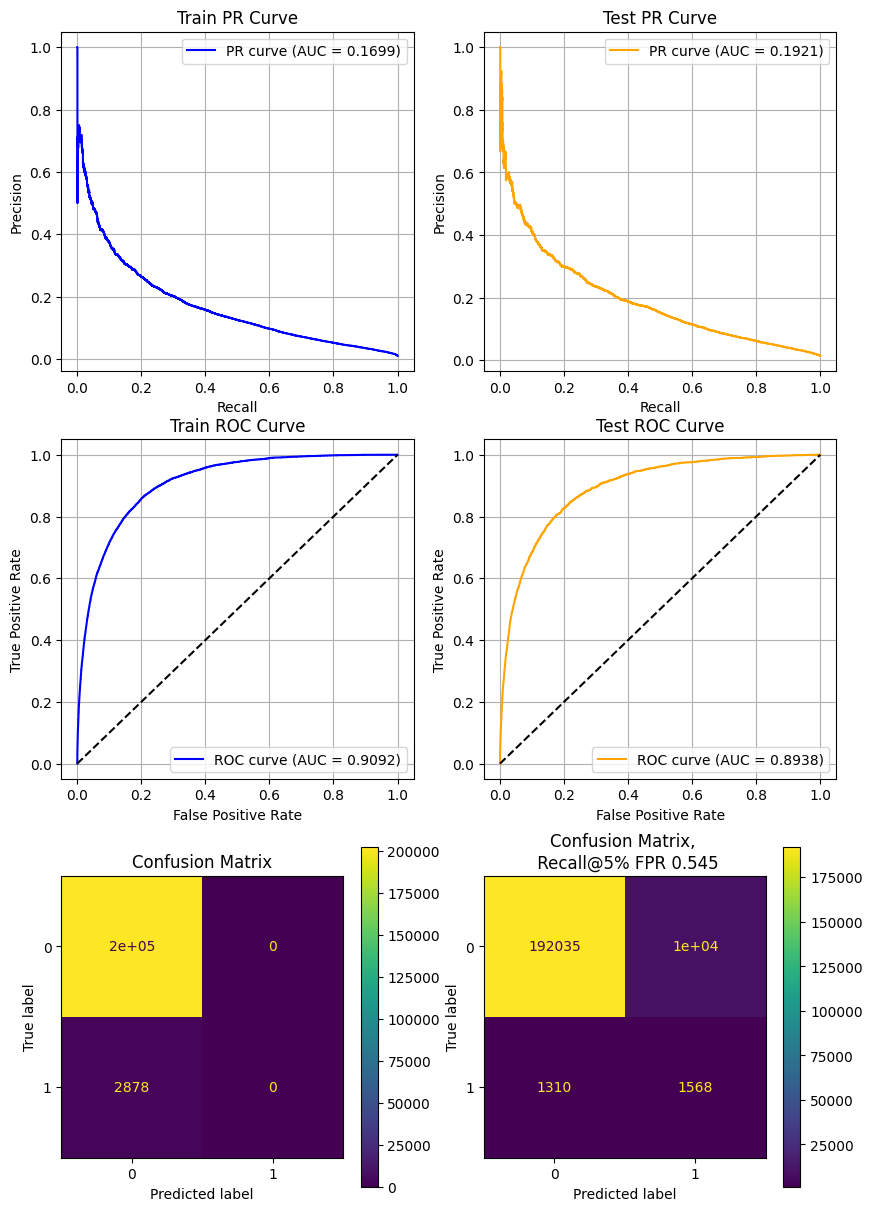

In [82]:
model_report(
    wrapped_classifier,
    X_train, y_train, 
    X_test, y_test,
)

plt.show()

^^^ After calibration base confusion matrix (with threshold == 0.5) shows incorrect results

# Conclusion

In this notebook, a classification model was trained, and hyperparameter tuning was performed using GridSearchCV and Optuna.
Two models showing the best cross-validation results were selected: RandomForest and XGBoost.

Next, a paired statistical test was conducted to check the equality of the mean values of the Recall@5% FPR metric for the two models. Based on the test results (p-value below the 0.05 significance level), the null hypothesis - that the average difference in metrics between the two models is zero - was rejected.

After that, probability calibration for the XGBoost model was performed using Platt’s method. The predicted probabilities of belonging to the positive class did not exceed 0.2.

Finally, a model wrapper was implemented, overriding the predict method so that the FPR on the test set is approximately 5%. The wrapper also returns the maximum probability of belonging to the positive class for instances where the device_fraud_count feature is greater than 0 (in the training set this feature was constant and was not used in training).